# 10 clients GRU: Lightweight Federated IDS

Notebook này tái hiện phần **adaptive federated mutual learning** của bài báo
“Lightweight Federated Learning for On-Device Non-Intrusive Load Monitoring”
trên CICIoT2023. Hai process tồn tại suốt phiên, mỗi process sở hữu một T4 và
huấn luyện một nhóm client độc lập; coordinator chỉ tổng hợp proxy sau mỗi round.

## Những điều chỉnh ngắn so với paper gốc

- NILM hồi quy trên REFIT/REDD được thay bằng phân loại 34 lớp trên dữ liệu
  CICIoT2023 đã chọn 25 đặc trưng và chuẩn hóa sẵn.
- Personalized model của client dùng cấu hình `10 clients GRU`;
  mỗi client đồng thời giữ một proxy CNN-1D `[32, 64, 128]`, kernel 3.
- Không chạy MNAS vì kiến trúc personalized model đã được cố định để so sánh.
- Label loss L2 của paper được thay bằng cross-entropy; sai khác distillation là
  MSE giữa hai phân phối softmax. Chỉ proxy được FedAvg có trọng số.
- Tất cả model cùng họ dùng initial state sinh độc lập từ seed 42; initial state
  và SHA-256 được nhúng trong checkpoint để đối chiếu giữa notebook.
- Client được chia tĩnh theo benchmark workload để cân bằng hai GPU; dữ liệu của
  client được cache trên GPU sở hữu với ngân sách 70% VRAM và LRU xác định khi
  không đủ chỗ. Notebook tự benchmark 1/2 CUDA stream và chỉ dùng 2 khi nhanh hơn.

In [1]:
import platform
import sys

import torch

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
n_gpu = torch.cuda.device_count()
for gpu_index in range(n_gpu):
    properties = torch.cuda.get_device_properties(gpu_index)
    print(
        f"GPU[{gpu_index}]: {properties.name}; "
        f"VRAM={properties.total_memory / 1024**3:.2f} GiB; "
        f"compute={properties.major}.{properties.minor}"
    )
assert torch.cuda.is_available(), "Enable a GPU accelerator in Kaggle settings."
assert n_gpu == 2, "Set the Kaggle accelerator to GPU T4 x2."
assert all("T4" in torch.cuda.get_device_name(i) for i in range(n_gpu))

Python: 3.12.13
Platform: Linux-6.12.90+-x86_64-with-glibc2.35
PyTorch: 2.10.0+cu128
CUDA available: True
GPU[0]: Tesla T4; VRAM=14.56 GiB; compute=7.5
GPU[1]: Tesla T4; VRAM=14.56 GiB; compute=7.5


## Công thức được thực thi

Với `n_k` là số mẫu train sau khi tách validation, proxy được tổng hợp:

$$w_G^{t+1}=\sum_{k=1}^{K}\frac{n_k}{\sum_j n_j}w_{r,k}^{t+1}.$$

Hai label loss:

$$\ell_s=\mathrm{CE}(y,z_s),\qquad \ell_r=\mathrm{CE}(y,z_r).$$

Adaptive mutual distillation, là ánh xạ phân loại của (17)–(19):

$$d=\mathrm{MSE}(\mathrm{softmax}(z_s),\mathrm{softmax}(z_r)),$$

$$\ell_d=\frac{d}{\mathrm{stopgrad}(\ell_s+\ell_r)+10^{-8}},$$

$$L_s=\ell_s+\ell_d,\qquad L_r=\ell_r+\ell_d.$$

Một backward chung trên `ℓs + ℓr + ℓd` truyền đúng một lần gradient
distillation vào mỗi model. Công thức MI/NAS của paper chỉ mang tính mô tả vì
input đã được chọn 25 đặc trưng bằng XGBoost và kiến trúc không còn được search.

In [2]:
import json
import logging
import os
import random
import subprocess
import sys
import time
import traceback
from pathlib import Path

import numpy as np
import pandas as pd

CONFIG = {
    "input_dir": "/kaggle/input/datasets/odixe0502/data-for-10clients",
    "run_name": "fd_ids_ciciot2023_10c_gru",
    "scenario_name": "10 clients GRU",
    "scenario_model_family": "gru",
    "client_architectures": [
        "gru",
        "gru",
        "gru",
        "gru",
        "gru",
        "gru",
        "gru",
        "gru",
        "gru",
        "gru"
    ],
    "proxy_model_family": "cnn1d",
    "num_clients": 10,
    "num_features": 25,
    "num_classes": 34,
    "feature_columns": [
        "ack_flag_number",
        "AVG",
        "Std",
        "UDP",
        "fin_count",
        "Max",
        "TCP",
        "syn_count",
        "Protocol Type",
        "Rate",
        "IAT",
        "syn_flag_number",
        "rst_flag_number",
        "Tot sum",
        "HTTPS",
        "ack_count",
        "fin_flag_number",
        "HTTP",
        "rst_count",
        "Header_Length",
        "psh_flag_number",
        "ICMP",
        "Time_To_Live",
        "ARP",
        "DNS"
    ],
    "execution_mode": "client_parallel",
    "gpu_worker_count": 2,
    "communication_rounds": 10,
    "local_epochs": 1,
    "final_personalized_finetune_epochs": 1,
    "per_client_batch_size": 1024,
    "gpu_cache_fraction": 0.7,
    "gpu_cache_chunk_rows": 200000,
    "stream_candidates": [
        1,
        2
    ],
    "stream_min_speedup": 1.03,
    "benchmark_warmup_steps": 3,
    "benchmark_timed_steps": 8,
    "stream_benchmark_warmup_steps": 2,
    "stream_benchmark_timed_steps": 6,
    "gpu_monitor_interval_seconds": 1.0,
    "worker_health_poll_seconds": 10.0,
    "worker_join_timeout_seconds": 30.0,
    "omp_num_threads_per_process": 1,
    "optimizer": "Adam",
    "learning_rate": 0.001,
    "scheduler": None,
    "label_loss": "cross_entropy",
    "distillation_discrepancy": "mse_softmax",
    "adaptive_epsilon": 1e-08,
    "validation_ratio": 0.05,
    "class_weighting": None,
    "checkpoint_criterion": "validation_macro_f1",
    "seed": 42,
    "initialization_seed": 42,
    "csv_chunk_rows": 200000
}
assert CONFIG["gpu_worker_count"] == n_gpu == 2
assert CONFIG["execution_mode"] == "client_parallel"
assert CONFIG["per_client_batch_size"] == 1024
assert CONFIG["client_architectures"] == ['gru', 'gru', 'gru', 'gru', 'gru', 'gru', 'gru', 'gru', 'gru', 'gru']

FEATURE_COLUMNS = CONFIG["feature_columns"]
INPUT_DIR = Path(CONFIG["input_dir"])
CLIENT_FILES = [
    INPUT_DIR / f"client_{client_id}_train.csv"
    for client_id in range(1, CONFIG["num_clients"] + 1)
]
GLOBAL_TEST_FILE = INPUT_DIR / "global_test_data.csv"
GLOBAL_TRAIN_FILE = INPUT_DIR / "global_train_data.csv"
LABEL_FILE = INPUT_DIR / "label_mapping.csv"
OUT = Path("/kaggle/working") / CONFIG["run_name"]
CACHE = Path("/kaggle/temp") / f"{CONFIG['run_name']}_cache"
for directory in ("checkpoints", "logs", "metrics", "artifacts"):
    (OUT / directory).mkdir(parents=True, exist_ok=True)
CACHE.mkdir(parents=True, exist_ok=True)

LOG_FILE = OUT / "logs" / "run.log"
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
    handlers=[
        logging.FileHandler(LOG_FILE, mode="w", encoding="utf-8"),
        logging.StreamHandler(sys.stdout),
    ],
    force=True,
)
logger = logging.getLogger("training")
logger.info("Run %s started", CONFIG["run_name"])
logger.info("Config: %s", json.dumps(CONFIG, sort_keys=True))

2026-07-30 14:24:42 | INFO | Run fd_ids_ciciot2023_10c_gru started
2026-07-30 14:24:42 | INFO | Config: {"adaptive_epsilon": 1e-08, "benchmark_timed_steps": 8, "benchmark_warmup_steps": 3, "checkpoint_criterion": "validation_macro_f1", "class_weighting": null, "client_architectures": ["gru", "gru", "gru", "gru", "gru", "gru", "gru", "gru", "gru", "gru"], "communication_rounds": 10, "csv_chunk_rows": 200000, "distillation_discrepancy": "mse_softmax", "execution_mode": "client_parallel", "feature_columns": ["ack_flag_number", "AVG", "Std", "UDP", "fin_count", "Max", "TCP", "syn_count", "Protocol Type", "Rate", "IAT", "syn_flag_number", "rst_flag_number", "Tot sum", "HTTPS", "ack_count", "fin_flag_number", "HTTP", "rst_count", "Header_Length", "psh_flag_number", "ICMP", "Time_To_Live", "ARP", "DNS"], "final_personalized_finetune_epochs": 1, "gpu_cache_chunk_rows": 200000, "gpu_cache_fraction": 0.7, "gpu_monitor_interval_seconds": 1.0, "gpu_worker_count": 2, "initialization_seed": 42, "inp

## Kiểm tra dữ liệu và tạo cache memmap

Cell này kiểm tra schema, tách validation theo lớp và không đưa `global_test_data.csv` vào chọn checkpoint.

In [3]:
def validate_header(csv_path):
    columns = pd.read_csv(csv_path, nrows=0).columns.tolist()
    expected = FEATURE_COLUMNS + ["Label"]
    if columns != expected:
        raise ValueError(
            f"Unexpected columns in {csv_path.name}.\n"
            f"Expected: {expected}\nObserved: {columns}"
        )


def scan_labels(csv_path):
    validate_header(csv_path)
    counts = np.zeros(CONFIG["num_classes"], dtype=np.int64)
    row_count = 0
    for chunk in pd.read_csv(
        csv_path,
        usecols=["Label"],
        dtype={"Label": np.int64},
        chunksize=CONFIG["csv_chunk_rows"],
    ):
        labels = chunk["Label"].to_numpy(dtype=np.int64, copy=False)
        if labels.size and (labels.min() < 0 or labels.max() >= CONFIG["num_classes"]):
            raise ValueError(f"Label outside [0, 33] in {csv_path}")
        counts += np.bincount(labels, minlength=CONFIG["num_classes"])
        row_count += labels.size
    return int(row_count), counts


def csv_to_memmaps(csv_path, x_path, y_path, row_count):
    x_map = np.lib.format.open_memmap(
        x_path,
        mode="w+",
        dtype=np.float32,
        shape=(row_count, len(FEATURE_COLUMNS)),
    )
    y_map = np.lib.format.open_memmap(
        y_path,
        mode="w+",
        dtype=np.int64,
        shape=(row_count,),
    )
    offset = 0
    for chunk in pd.read_csv(
        csv_path,
        dtype={**{name: np.float32 for name in FEATURE_COLUMNS}, "Label": np.int64},
        chunksize=CONFIG["csv_chunk_rows"],
    ):
        features = chunk[FEATURE_COLUMNS].to_numpy(dtype=np.float32, copy=False)
        labels = chunk["Label"].to_numpy(dtype=np.int64, copy=False)
        if not np.isfinite(features).all():
            raise ValueError(f"NaN or infinity found in {csv_path}")
        end = offset + len(chunk)
        x_map[offset:end] = features
        y_map[offset:end] = labels
        offset = end
    if offset != row_count:
        raise RuntimeError(f"Row count changed while reading {csv_path}")
    x_map.flush()
    y_map.flush()
    del x_map, y_map


def make_stratified_indices(y_path, row_count, class_counts, client_id):
    labels = np.load(y_path, mmap_mode="r")
    val_mask_path = CACHE / f"client_{client_id}_val_mask.npy"
    val_mask = np.lib.format.open_memmap(
        val_mask_path,
        mode="w+",
        dtype=np.uint8,
        shape=(row_count,),
    )
    val_mask[:] = 0
    val_counts = np.zeros(CONFIG["num_classes"], dtype=np.int64)
    rng = np.random.default_rng(CONFIG["seed"] + 10_000 + client_id)
    for class_id, class_count in enumerate(class_counts.tolist()):
        if class_count <= 1:
            continue
        requested = int(round(class_count * CONFIG["validation_ratio"]))
        val_count = min(class_count - 1, max(1, requested))
        positions = np.flatnonzero(labels == class_id)
        if len(positions) != class_count:
            raise RuntimeError(f"Class count mismatch for client {client_id}")
        chosen = rng.choice(positions, size=val_count, replace=False, shuffle=False)
        val_mask[chosen] = 1
        val_counts[class_id] = val_count
        del positions, chosen
    val_mask.flush()

    train_count = int(row_count - val_counts.sum())
    val_count = int(val_counts.sum())
    train_index_path = CACHE / f"client_{client_id}_train_indices.npy"
    val_index_path = CACHE / f"client_{client_id}_val_indices.npy"
    train_indices = np.lib.format.open_memmap(
        train_index_path,
        mode="w+",
        dtype=np.int64,
        shape=(train_count,),
    )
    val_indices = np.lib.format.open_memmap(
        val_index_path,
        mode="w+",
        dtype=np.int64,
        shape=(val_count,),
    )
    train_indices[:] = np.flatnonzero(val_mask == 0)
    val_indices[:] = np.flatnonzero(val_mask == 1)
    train_indices.flush()
    val_indices.flush()
    del labels, val_mask, train_indices, val_indices
    val_mask_path.unlink()
    return train_index_path, val_index_path, class_counts - val_counts, val_counts


pipeline_started = time.perf_counter()
preprocessing_started = time.perf_counter()
for required_path in CLIENT_FILES + [GLOBAL_TEST_FILE, GLOBAL_TRAIN_FILE, LABEL_FILE]:
    if not required_path.is_file():
        raise FileNotFoundError(f"Required Kaggle input is missing: {required_path}")

label_frame = pd.read_csv(LABEL_FILE)
if label_frame.columns.tolist() != ["Encoded_ID", "Label_Name"]:
    raise ValueError("label_mapping.csv must contain Encoded_ID,Label_Name")
label_frame = label_frame.sort_values("Encoded_ID").reset_index(drop=True)
expected_ids = list(range(CONFIG["num_classes"]))
if label_frame["Encoded_ID"].astype(int).tolist() != expected_ids:
    raise ValueError("Encoded_ID must be exactly 0..33")
LABEL_MAPPING = {
    int(row.Encoded_ID): str(row.Label_Name)
    for row in label_frame.itertuples(index=False)
}
BENIGN_CLASS_ID = next(
    class_id
    for class_id, name in LABEL_MAPPING.items()
    if name.upper() in {"BENIGN", "BENIGNTRAFFIC"}
)

client_scans = {}
for client_id, csv_path in enumerate(CLIENT_FILES, start=1):
    row_count, class_counts = scan_labels(csv_path)
    client_scans[client_id] = {
        "row_count": row_count,
        "class_counts": class_counts,
    }
    logger.info("Scanned client %d: %s rows", client_id, f"{row_count:,}")

global_train_rows, _ = scan_labels(GLOBAL_TRAIN_FILE)
client_row_sum = sum(item["row_count"] for item in client_scans.values())
if global_train_rows != client_row_sum:
    raise RuntimeError(
        f"global_train_data.csv has {global_train_rows:,} rows, "
        f"but clients sum to {client_row_sum:,}"
    )
test_rows, test_class_counts = scan_labels(GLOBAL_TEST_FILE)
logger.info("Scanned global test: %s rows", f"{test_rows:,}")

client_manifest = {}
distribution_rows = []
for client_id, csv_path in enumerate(CLIENT_FILES, start=1):
    row_count = client_scans[client_id]["row_count"]
    class_counts = client_scans[client_id]["class_counts"]
    x_path = CACHE / f"client_{client_id}_features.npy"
    y_path = CACHE / f"client_{client_id}_labels.npy"
    csv_to_memmaps(csv_path, x_path, y_path, row_count)
    train_index_path, val_index_path, train_counts, val_counts = (
        make_stratified_indices(
            y_path,
            row_count,
            class_counts,
            client_id,
        )
    )
    client_manifest[str(client_id)] = {
        "client_id": client_id,
        "architecture": CONFIG["client_architectures"][client_id - 1],
        "features_path": str(x_path),
        "labels_path": str(y_path),
        "train_indices_path": str(train_index_path),
        "val_indices_path": str(val_index_path),
        "original_examples": row_count,
        "train_examples": int(train_counts.sum()),
        "validation_examples": int(val_counts.sum()),
        "original_class_counts": class_counts.tolist(),
        "train_class_counts": train_counts.tolist(),
        "validation_class_counts": val_counts.tolist(),
    }
    for class_id in range(CONFIG["num_classes"]):
        distribution_rows.append(
            {
                "client_id": client_id,
                "architecture": CONFIG["client_architectures"][client_id - 1],
                "class_id": class_id,
                "class_name": LABEL_MAPPING[class_id],
                "original_examples": int(class_counts[class_id]),
                "train_examples": int(train_counts[class_id]),
                "validation_examples": int(val_counts[class_id]),
            }
        )
    logger.info(
        "Cached client %d: train=%s validation=%s",
        client_id,
        f"{int(train_counts.sum()):,}",
        f"{int(val_counts.sum()):,}",
    )

test_x_path = CACHE / "global_test_features.npy"
test_y_path = CACHE / "global_test_labels.npy"
csv_to_memmaps(GLOBAL_TEST_FILE, test_x_path, test_y_path, test_rows)
preprocessing_seconds = time.perf_counter() - preprocessing_started

confirmed_data_manifest = {
    "input_dir": str(INPUT_DIR),
    "clients": client_manifest,
    "test": {
        "features_path": str(test_x_path),
        "labels_path": str(test_y_path),
        "examples": test_rows,
        "class_counts": test_class_counts.tolist(),
    },
    "global_train_rows": global_train_rows,
    "label_mapping": LABEL_MAPPING,
    "benign_class_id": BENIGN_CLASS_ID,
}
dataset_summary = {
    "input_dir": str(INPUT_DIR),
    "feature_columns": FEATURE_COLUMNS,
    "num_features": len(FEATURE_COLUMNS),
    "num_classes": CONFIG["num_classes"],
    "global_train_rows": global_train_rows,
    "client_train_rows_after_validation": sum(
        item["train_examples"] for item in client_manifest.values()
    ),
    "client_validation_rows": sum(
        item["validation_examples"] for item in client_manifest.values()
    ),
    "global_test_rows": test_rows,
    "clients": client_manifest,
    "test_class_counts": test_class_counts.tolist(),
}
(OUT / "metrics" / "config.json").write_text(
    json.dumps(CONFIG, indent=2, sort_keys=True),
    encoding="utf-8",
)
(OUT / "metrics" / "dataset_summary.json").write_text(
    json.dumps(dataset_summary, indent=2),
    encoding="utf-8",
)
pd.DataFrame(distribution_rows).to_csv(
    OUT / "metrics" / "client_class_distribution.csv",
    index=False,
)
logger.info("Preprocessing completed in %.2f seconds", preprocessing_seconds)

2026-07-30 14:24:42 | INFO | Scanned client 1: 31,520 rows
2026-07-30 14:24:49 | INFO | Scanned client 2: 2,211,589 rows
2026-07-30 14:25:00 | INFO | Scanned client 3: 3,728,450 rows
2026-07-30 14:25:06 | INFO | Scanned client 4: 1,920,254 rows
2026-07-30 14:25:14 | INFO | Scanned client 5: 2,531,881 rows
2026-07-30 14:25:23 | INFO | Scanned client 6: 2,686,617 rows
2026-07-30 14:25:28 | INFO | Scanned client 7: 1,824,975 rows
2026-07-30 14:26:05 | INFO | Scanned client 8: 12,759,509 rows
2026-07-30 14:26:16 | INFO | Scanned client 9: 4,354,192 rows
2026-07-30 14:26:28 | INFO | Scanned client 10: 3,965,607 rows
2026-07-30 14:28:50 | INFO | Scanned global test: 9,003,649 rows
2026-07-30 14:28:51 | INFO | Cached client 1: train=29,942 validation=1,578
2026-07-30 14:28:59 | INFO | Cached client 2: train=2,101,011 validation=110,578
2026-07-30 14:29:13 | INFO | Cached client 3: train=3,542,026 validation=186,424
2026-07-30 14:29:20 | INFO | Cached client 4: train=1,824,241 validation=96,01

## Runtime client-parallel

Runtime dùng `spawn`, hai worker GPU bền vững và coordinator CPU; không khởi tạo process group.

In [4]:
CLIENT_PARALLEL_RUNTIME_SOURCE = 'from __future__ import annotations\n\nimport hashlib\nimport json\nimport logging\nimport math\nimport multiprocessing\nimport os\nimport queue\nimport random\nimport subprocess\nimport sys\nimport threading\nimport time\nimport traceback\nfrom collections import OrderedDict\nfrom pathlib import Path\n\nimport numpy as np\nimport pandas as pd\nimport torch\nimport torch.nn as nn\nimport torch.nn.functional as F\n\n\nMANIFEST_PATH = Path(os.environ["TRAINING_MANIFEST"])\nMANIFEST = json.loads(MANIFEST_PATH.read_text(encoding="utf-8"))\nCONFIG = MANIFEST["config"]\nDATA = MANIFEST["confirmed_data"]\nOUT = Path(MANIFEST["out_dir"])\nCACHE_DIR = Path(MANIFEST["cache_dir"])\nFEATURE_COLUMNS = CONFIG["feature_columns"]\nLABEL_MAPPING = {int(key): value for key, value in DATA["label_mapping"].items()}\nBENIGN_CLASS_ID = int(DATA["benign_class_id"])\nMIB = 1024 ** 2\n\n\nclass GRUClassifier(nn.Module):\n    def __init__(self):\n        super().__init__()\n        self.gru = nn.GRU(\n            input_size=1,\n            hidden_size=64,\n            num_layers=2,\n            dropout=0.2,\n            batch_first=True,\n        )\n        self.classifier = nn.Linear(64, CONFIG["num_classes"])\n\n    def forward(self, features):\n        sequence = features.unsqueeze(-1)\n        encoded, _ = self.gru(sequence)\n        return self.classifier(encoded[:, -1, :])\n\n\nclass TransformerClassifier(nn.Module):\n    def __init__(self):\n        super().__init__()\n        self.scalar_projection = nn.Linear(1, 64)\n        self.position = nn.Parameter(torch.empty(1, CONFIG["num_features"], 64))\n        layer = nn.TransformerEncoderLayer(\n            d_model=64,\n            nhead=4,\n            dim_feedforward=128,\n            dropout=0.1,\n            activation="relu",\n            batch_first=True,\n            norm_first=False,\n        )\n        self.encoder = nn.TransformerEncoder(layer, num_layers=2)\n        self.norm = nn.LayerNorm(64)\n        self.classifier = nn.Linear(64, CONFIG["num_classes"])\n        nn.init.normal_(self.position, mean=0.0, std=0.02)\n\n    def forward(self, features):\n        tokens = self.scalar_projection(features.unsqueeze(-1)) + self.position\n        encoded = self.encoder(tokens)\n        return self.classifier(self.norm(encoded.mean(dim=1)))\n\n\nclass CNN1DProxy(nn.Module):\n    def __init__(self):\n        super().__init__()\n        self.features = nn.Sequential(\n            nn.Conv1d(1, 32, kernel_size=3, padding=1),\n            nn.BatchNorm1d(32),\n            nn.ReLU(inplace=True),\n            nn.Conv1d(32, 64, kernel_size=3, padding=1),\n            nn.BatchNorm1d(64),\n            nn.ReLU(inplace=True),\n            nn.MaxPool1d(kernel_size=2),\n            nn.Conv1d(64, 128, kernel_size=3, padding=1),\n            nn.BatchNorm1d(128),\n            nn.ReLU(inplace=True),\n            nn.AdaptiveAvgPool1d(1),\n        )\n        self.classifier = nn.Linear(128, CONFIG["num_classes"])\n\n    def forward(self, features):\n        encoded = self.features(features.unsqueeze(1)).squeeze(-1)\n        return self.classifier(encoded)\n\n\ndef build_model(family):\n    if family == "gru":\n        return GRUClassifier()\n    if family == "transformer":\n        return TransformerClassifier()\n    if family == "cnn1d":\n        return CNN1DProxy()\n    raise ValueError(f"Unknown model family: {family}")\n\n\ndef cpu_state(model):\n    return OrderedDict(\n        (key, tensor.detach().cpu().clone())\n        for key, tensor in model.state_dict().items()\n    )\n\n\ndef clone_state(state):\n    return OrderedDict((key, tensor.clone()) for key, tensor in state.items())\n\n\ndef make_initial_state(family):\n    with torch.random.fork_rng(devices=[]):\n        torch.manual_seed(CONFIG["initialization_seed"])\n        model = build_model(family)\n    return cpu_state(model)\n\n\ndef state_sha256(state):\n    digest = hashlib.sha256()\n    for key, tensor in state.items():\n        digest.update(key.encode("utf-8"))\n        array = tensor.detach().cpu().contiguous().numpy()\n        digest.update(str(array.dtype).encode("ascii"))\n        digest.update(np.asarray(array.shape, dtype=np.int64).tobytes())\n        digest.update(array.tobytes())\n    return digest.hexdigest()\n\n\ndef model_metadata(family, state):\n    model = build_model(family)\n    trainable_parameters = sum(\n        parameter.numel() for parameter in model.parameters() if parameter.requires_grad\n    )\n    trainable_bytes = sum(\n        parameter.numel() * parameter.element_size()\n        for parameter in model.parameters()\n        if parameter.requires_grad\n    )\n    state_bytes = sum(tensor.numel() * tensor.element_size() for tensor in state.values())\n    return {\n        "model_family": family,\n        "total_parameters": sum(parameter.numel() for parameter in model.parameters()),\n        "trainable_parameters": trainable_parameters,\n        "trainable_parameter_bytes": trainable_bytes,\n        "model_state_bytes": state_bytes,\n        "model_state_mib": state_bytes / MIB,\n        "initialization_sha256": state_sha256(state),\n    }\n\n\ndef safe_divide(numerator, denominator):\n    return np.divide(\n        numerator,\n        denominator,\n        out=np.zeros_like(numerator, dtype=np.float64),\n        where=denominator != 0,\n    )\n\n\ndef metrics_from_confusion(matrix):\n    matrix = np.asarray(matrix, dtype=np.int64)\n    support = matrix.sum(axis=1).astype(np.float64)\n    predicted = matrix.sum(axis=0).astype(np.float64)\n    true_positive = np.diag(matrix).astype(np.float64)\n    total = float(matrix.sum())\n    false_positive = predicted - true_positive\n    false_negative = support - true_positive\n    true_negative = total - true_positive - false_positive - false_negative\n    precision = safe_divide(true_positive, true_positive + false_positive)\n    recall = safe_divide(true_positive, true_positive + false_negative)\n    f1 = safe_divide(2.0 * precision * recall, precision + recall)\n    fpr = safe_divide(false_positive, false_positive + true_negative)\n    fnr = safe_divide(false_negative, false_negative + true_positive)\n    weights = safe_divide(support, np.full_like(support, max(total, 1.0)))\n\n    benign_tp = float(matrix[BENIGN_CLASS_ID, BENIGN_CLASS_ID])\n    benign_as_attack = float(matrix[BENIGN_CLASS_ID].sum() - benign_tp)\n    attack_as_benign = float(matrix[:, BENIGN_CLASS_ID].sum() - benign_tp)\n    attack_tp = total - benign_tp - benign_as_attack - attack_as_benign\n    attack_precision = attack_tp / max(attack_tp + benign_as_attack, 1.0)\n    attack_recall = attack_tp / max(attack_tp + attack_as_benign, 1.0)\n    attack_f1 = (\n        2.0 * attack_precision * attack_recall\n        / max(attack_precision + attack_recall, 1e-15)\n    )\n    binary_accuracy = (attack_tp + benign_tp) / max(total, 1.0)\n    binary_fpr = benign_as_attack / max(benign_as_attack + benign_tp, 1.0)\n    binary_fnr = attack_as_benign / max(attack_as_benign + attack_tp, 1.0)\n    return {\n        "accuracy": float(true_positive.sum() / max(total, 1.0)),\n        "macro_precision": float(precision.mean()),\n        "macro_recall": float(recall.mean()),\n        "macro_f1": float(f1.mean()),\n        "weighted_precision": float((precision * weights).sum()),\n        "weighted_recall": float((recall * weights).sum()),\n        "weighted_f1": float((f1 * weights).sum()),\n        "multiclass_macro_fpr": float(fpr.mean()),\n        "multiclass_macro_fnr": float(fnr.mean()),\n        "binary_attack_accuracy": float(binary_accuracy),\n        "binary_attack_precision": float(attack_precision),\n        "binary_attack_recall": float(attack_recall),\n        "binary_attack_f1": float(attack_f1),\n        "binary_attack_fpr": float(binary_fpr),\n        "binary_attack_fnr": float(binary_fnr),\n    }\n\n\ndef prefixed_metrics(prefix, evaluation):\n    values = {f"{prefix}_loss": evaluation["loss"]}\n    values.update(\n        {f"{prefix}_{name}": value for name, value in evaluation["metrics"].items()}\n    )\n    return values\n\n\ndef json_ready(value):\n    if isinstance(value, dict):\n        return {str(key): json_ready(item) for key, item in value.items()}\n    if isinstance(value, (list, tuple)):\n        return [json_ready(item) for item in value]\n    if isinstance(value, np.ndarray):\n        return value.tolist()\n    if isinstance(value, np.integer):\n        return int(value)\n    if isinstance(value, np.floating):\n        return float(value)\n    return value\n\n\ndef write_json(path, value):\n    path.write_text(\n        json.dumps(json_ready(value), indent=2, sort_keys=False),\n        encoding="utf-8",\n    )\n\n\ndef classification_report_from_confusion(matrix):\n    matrix = np.asarray(matrix, dtype=np.int64)\n    support = matrix.sum(axis=1).astype(np.float64)\n    predicted = matrix.sum(axis=0).astype(np.float64)\n    true_positive = np.diag(matrix).astype(np.float64)\n    precision = safe_divide(true_positive, predicted)\n    recall = safe_divide(true_positive, support)\n    f1 = safe_divide(2.0 * precision * recall, precision + recall)\n    rows = []\n    report = {}\n    for class_id in range(CONFIG["num_classes"]):\n        row = {\n            "class_id": class_id,\n            "class_name": LABEL_MAPPING[class_id],\n            "precision": float(precision[class_id]),\n            "recall": float(recall[class_id]),\n            "f1": float(f1[class_id]),\n            "support": int(support[class_id]),\n        }\n        rows.append(row)\n        report[str(class_id)] = row\n    total = float(support.sum())\n    weights = safe_divide(support, np.full_like(support, max(total, 1.0)))\n    for name, values in (\n        ("macro avg", np.ones_like(support) / len(support)),\n        ("weighted avg", weights),\n    ):\n        row = {\n            "class_id": name,\n            "class_name": name,\n            "precision": float((precision * values).sum()),\n            "recall": float((recall * values).sum()),\n            "f1": float((f1 * values).sum()),\n            "support": int(total),\n        }\n        rows.append(row)\n        report[name] = row\n    return report, rows\n\n\ndef save_history(name, rows):\n    pd.DataFrame(rows).to_csv(OUT / "metrics" / f"{name}.csv", index=False)\n    write_json(OUT / "metrics" / f"{name}.json", rows)\n\n\ndef aggregate_proxy_states(states, weights):\n    total_weight = float(sum(weights))\n    aggregated = OrderedDict()\n    for key in states[0]:\n        tensors = [state[key] for state in states]\n        if tensors[0].is_floating_point():\n            accumulator = torch.zeros_like(tensors[0], dtype=torch.float64)\n            for tensor, weight in zip(tensors, weights):\n                accumulator.add_(tensor.to(torch.float64), alpha=weight / total_weight)\n            aggregated[key] = accumulator.to(tensors[0].dtype)\n        else:\n            aggregated[key] = torch.stack(tensors).max(dim=0).values\n    return aggregated\n\n\ndef derive_seed(round_index, client_id, phase):\n    phase_code = {\n        "mutual": 11,\n        "finetune": 29,\n        "validation": 43,\n        "test": 61,\n    }[phase]\n    return (\n        CONFIG["seed"] * 1_000_003\n        + round_index * 10_007\n        + client_id * 101\n        + phase_code\n    ) % (2 ** 31 - 1)\n\n\ndef setup_logger(log_path, name, include_stdout=False):\n    handlers = [logging.FileHandler(log_path, mode="a", encoding="utf-8")]\n    if include_stdout:\n        handlers.append(logging.StreamHandler(sys.stdout))\n    logging.basicConfig(\n        level=logging.INFO,\n        format="%(asctime)s | %(levelname)s | %(message)s",\n        datefmt="%Y-%m-%d %H:%M:%S",\n        handlers=handlers,\n        force=True,\n    )\n    return logging.getLogger(name)\n\n\ndef numpy_file_bytes(path):\n    array = np.load(path, mmap_mode="r")\n    return int(array.nbytes)\n\n\ndef torch_dtype_for_numpy(dtype):\n    mapping = {\n        np.dtype("float32"): torch.float32,\n        np.dtype("float64"): torch.float64,\n        np.dtype("int64"): torch.int64,\n        np.dtype("int32"): torch.int32,\n        np.dtype("uint8"): torch.uint8,\n    }\n    if np.dtype(dtype) not in mapping:\n        raise TypeError(f"Unsupported cache dtype: {dtype}")\n    return mapping[np.dtype(dtype)]\n\n\ndef validate_numpy_classification_cache(\n    features_path,\n    labels_path,\n    owner,\n    index_paths=None,\n):\n    features = np.load(features_path, mmap_mode="r")\n    labels = np.load(labels_path, mmap_mode="r")\n    expected_feature_shape = (len(labels), CONFIG["num_features"])\n    if features.shape != expected_feature_shape:\n        raise ValueError(\n            f"{owner} feature shape must be {expected_feature_shape}, "\n            f"observed {features.shape}"\n        )\n    if features.dtype != np.dtype("float32"):\n        raise TypeError(\n            f"{owner} features must use float32, observed {features.dtype}"\n        )\n    if labels.ndim != 1 or labels.dtype != np.dtype("int64"):\n        raise TypeError(\n            f"{owner} labels must be one-dimensional int64, "\n            f"observed shape={labels.shape} dtype={labels.dtype}"\n        )\n    if labels.size:\n        label_min = int(labels.min())\n        label_max = int(labels.max())\n        if label_min < 0 or label_max >= CONFIG["num_classes"]:\n            raise ValueError(\n                f"{owner} labels must be in [0, {CONFIG[\'num_classes\'] - 1}], "\n                f"observed [{label_min}, {label_max}]"\n            )\n\n    indexed_rows = 0\n    for index_name, index_path in (index_paths or {}).items():\n        indices = np.load(index_path, mmap_mode="r")\n        if indices.ndim != 1 or indices.dtype != np.dtype("int64"):\n            raise TypeError(\n                f"{owner} {index_name} must be one-dimensional int64, "\n                f"observed shape={indices.shape} dtype={indices.dtype}"\n            )\n        if indices.size:\n            index_min = int(indices.min())\n            index_max = int(indices.max())\n            if index_min < 0 or index_max >= len(labels):\n                raise IndexError(\n                    f"{owner} {index_name} must index [0, {len(labels) - 1}], "\n                    f"observed [{index_min}, {index_max}]"\n                )\n        indexed_rows += len(indices)\n    if index_paths and indexed_rows != len(labels):\n        raise ValueError(\n            f"{owner} train/validation indices cover {indexed_rows} rows, "\n            f"expected {len(labels)}"\n        )\n\n\ndef load_numpy_to_device(path, device, chunk_rows, copy_stream):\n    source = np.load(path, mmap_mode="r")\n    destination = torch.empty(\n        source.shape,\n        dtype=torch_dtype_for_numpy(source.dtype),\n        device=device,\n    )\n    total_rows = source.shape[0] if source.ndim else 1\n    for start in range(0, total_rows, chunk_rows):\n        end = min(total_rows, start + chunk_rows)\n        cpu_array = np.array(source[start:end], copy=True)\n        cpu_tensor = torch.from_numpy(cpu_array)\n        pinned = torch.empty_like(cpu_tensor, pin_memory=True)\n        pinned.copy_(cpu_tensor)\n        with torch.cuda.stream(copy_stream):\n            destination[start:end].copy_(pinned, non_blocking=True)\n        copy_stream.synchronize()\n    return destination\n\n\nclass GpuClientCache:\n    def __init__(self, gpu_id, assigned_clients, device, logger):\n        self.gpu_id = gpu_id\n        self.assigned_clients = tuple(assigned_clients)\n        self.device = device\n        self.logger = logger\n        self.copy_stream = torch.cuda.Stream(device=device)\n        self.total_vram_bytes = torch.cuda.get_device_properties(gpu_id).total_memory\n        self.cache_budget_bytes = int(\n            self.total_vram_bytes * CONFIG["gpu_cache_fraction"]\n        )\n        self.client_bytes = {\n            client_id: self._estimate_client_bytes(client_id)\n            for client_id in self.assigned_clients\n        }\n        self.planned_bytes = sum(self.client_bytes.values())\n        self.entries = OrderedDict()\n        self.current_bytes = 0\n        self.hits = 0\n        self.misses = 0\n        self.evictions = 0\n        self.validated_clients = set()\n        self.mode = (\n            "full_gpu_cache"\n            if self.planned_bytes <= self.cache_budget_bytes\n            else "deterministic_lru_gpu_cache"\n        )\n        if self.mode == "full_gpu_cache":\n            self.ensure(self.assigned_clients)\n\n    def _paths(self, client_id):\n        item = DATA["clients"][str(client_id)]\n        return {\n            "features": item["features_path"],\n            "labels": item["labels_path"],\n            "train_indices": item["train_indices_path"],\n            "val_indices": item["val_indices_path"],\n        }\n\n    def _estimate_client_bytes(self, client_id):\n        return sum(numpy_file_bytes(path) for path in self._paths(client_id).values())\n\n    def _load_client(self, client_id):\n        paths = self._paths(client_id)\n        if client_id not in self.validated_clients:\n            validate_numpy_classification_cache(\n                paths["features"],\n                paths["labels"],\n                f"client {client_id}",\n                {\n                    "train_indices": paths["train_indices"],\n                    "val_indices": paths["val_indices"],\n                },\n            )\n            self.validated_clients.add(client_id)\n        loaded = {\n            name: load_numpy_to_device(\n                path,\n                self.device,\n                CONFIG["gpu_cache_chunk_rows"],\n                self.copy_stream,\n            )\n            for name, path in paths.items()\n        }\n        actual_bytes = sum(\n            tensor.numel() * tensor.element_size() for tensor in loaded.values()\n        )\n        return loaded, actual_bytes\n\n    def ensure(self, client_ids):\n        protected = set(client_ids)\n        for client_id in client_ids:\n            if client_id in self.entries:\n                self.hits += 1\n                self.entries.move_to_end(client_id)\n                continue\n            self.misses += 1\n            needed = self.client_bytes[client_id]\n            while self.current_bytes + needed > self.cache_budget_bytes:\n                eviction_id = next(\n                    (\n                        candidate\n                        for candidate in self.entries\n                        if candidate not in protected\n                    ),\n                    None,\n                )\n                if eviction_id is None:\n                    raise RuntimeError(\n                        f"GPU {self.gpu_id} cache cannot hold active clients "\n                        f"{sorted(protected)} within budget"\n                    )\n                entry = self.entries.pop(eviction_id)\n                self.current_bytes -= entry["actual_bytes"]\n                self.evictions += 1\n                del entry\n                torch.cuda.empty_cache()\n            tensors, actual_bytes = self._load_client(client_id)\n            self.entries[client_id] = {\n                **tensors,\n                "actual_bytes": actual_bytes,\n            }\n            self.current_bytes += actual_bytes\n            self.logger.info(\n                "Cached client %d on GPU %d: %.2f MiB",\n                client_id,\n                self.gpu_id,\n                actual_bytes / MIB,\n            )\n\n    def get(self, client_id):\n        self.ensure([client_id])\n        return self.entries[client_id]\n\n    def clear(self):\n        self.entries.clear()\n        self.current_bytes = 0\n        torch.cuda.empty_cache()\n\n    def stats(self):\n        return {\n            "gpu_id": self.gpu_id,\n            "mode": self.mode,\n            "cache_budget_bytes": self.cache_budget_bytes,\n            "cache_budget_mib": self.cache_budget_bytes / MIB,\n            "planned_bytes": self.planned_bytes,\n            "planned_mib": self.planned_bytes / MIB,\n            "current_bytes": self.current_bytes,\n            "current_mib": self.current_bytes / MIB,\n            "hits": self.hits,\n            "misses": self.misses,\n            "evictions": self.evictions,\n            "assigned_clients": list(self.assigned_clients),\n        }\n\n\ndef make_benchmark_pair(family, device, stream):\n    personal = build_model(family).to(device)\n    proxy = build_model("cnn1d").to(device)\n    optimizer = torch.optim.Adam(\n        list(personal.parameters()) + list(proxy.parameters()),\n        lr=CONFIG["learning_rate"],\n    )\n    scaler = torch.amp.GradScaler("cuda")\n    generator = torch.Generator(device=device)\n    generator.manual_seed(CONFIG["seed"] + 700 + len(family))\n    features = torch.randn(\n        CONFIG["per_client_batch_size"],\n        CONFIG["num_features"],\n        generator=generator,\n        device=device,\n    )\n    targets = torch.randint(\n        0,\n        CONFIG["num_classes"],\n        (CONFIG["per_client_batch_size"],),\n        generator=generator,\n        device=device,\n    )\n    return {\n        "family": family,\n        "personal": personal,\n        "proxy": proxy,\n        "optimizer": optimizer,\n        "scaler": scaler,\n        "features": features,\n        "targets": targets,\n        "stream": stream,\n    }\n\n\ndef enqueue_benchmark_step(context):\n    with torch.cuda.stream(context["stream"]):\n        context["optimizer"].zero_grad(set_to_none=True)\n        with torch.amp.autocast("cuda"):\n            personal_logits = context["personal"](context["features"])\n            proxy_logits = context["proxy"](context["features"])\n            personal_loss = F.cross_entropy(personal_logits, context["targets"])\n            proxy_loss = F.cross_entropy(proxy_logits, context["targets"])\n            discrepancy = F.mse_loss(\n                personal_logits.softmax(dim=1),\n                proxy_logits.softmax(dim=1),\n            )\n            adaptive = discrepancy / (\n                personal_loss.detach()\n                + proxy_loss.detach()\n                + CONFIG["adaptive_epsilon"]\n            )\n            loss = personal_loss + proxy_loss + adaptive\n        context["scaler"].scale(loss).backward()\n        context["scaler"].step(context["optimizer"])\n        context["scaler"].update()\n\n\ndef benchmark_single_family(family, device):\n    stream = torch.cuda.Stream(device=device)\n    context = make_benchmark_pair(family, device, stream)\n    for _ in range(CONFIG["benchmark_warmup_steps"]):\n        enqueue_benchmark_step(context)\n    stream.synchronize()\n    start = torch.cuda.Event(enable_timing=True)\n    end = torch.cuda.Event(enable_timing=True)\n    with torch.cuda.stream(stream):\n        start.record()\n    for _ in range(CONFIG["benchmark_timed_steps"]):\n        enqueue_benchmark_step(context)\n    with torch.cuda.stream(stream):\n        end.record()\n    stream.synchronize()\n    seconds = start.elapsed_time(end) / 1000.0\n    del context\n    torch.cuda.empty_cache()\n    return seconds / CONFIG["benchmark_timed_steps"]\n\n\ndef benchmark_stream_candidate(families, stream_count, device):\n    streams = [torch.cuda.Stream(device=device) for _ in range(stream_count)]\n    contexts = [\n        make_benchmark_pair(\n            family,\n            device,\n            streams[index % stream_count],\n        )\n        for index, family in enumerate(families)\n    ]\n    for _ in range(CONFIG["stream_benchmark_warmup_steps"]):\n        for context in contexts:\n            enqueue_benchmark_step(context)\n    for stream in streams:\n        stream.synchronize()\n    starts = [torch.cuda.Event(enable_timing=True) for _ in streams]\n    ends = [torch.cuda.Event(enable_timing=True) for _ in streams]\n    for stream, event in zip(streams, starts):\n        with torch.cuda.stream(stream):\n            event.record()\n    for _ in range(CONFIG["stream_benchmark_timed_steps"]):\n        for context in contexts:\n            enqueue_benchmark_step(context)\n    for stream, event in zip(streams, ends):\n        with torch.cuda.stream(stream):\n            event.record()\n    for stream in streams:\n        stream.synchronize()\n    elapsed_seconds = max(\n        start.elapsed_time(end) / 1000.0\n        for start, end in zip(starts, ends)\n    )\n    total_examples = (\n        len(contexts)\n        * CONFIG["stream_benchmark_timed_steps"]\n        * CONFIG["per_client_batch_size"]\n    )\n    result = {\n        "stream_count": stream_count,\n        "elapsed_seconds": elapsed_seconds,\n        "samples_per_second": total_examples / max(elapsed_seconds, 1e-12),\n        "families": list(families),\n    }\n    del contexts\n    torch.cuda.empty_cache()\n    return result\n\n\ndef choose_stream_count(assigned_clients, device):\n    ordered_families = [\n        CONFIG["client_architectures"][client_id - 1]\n        for client_id in assigned_clients\n    ]\n    unique_families = list(dict.fromkeys(ordered_families))\n    benchmark_families = (\n        unique_families[:2]\n        if len(unique_families) >= 2\n        else unique_families * 2\n    )\n    results = {\n        stream_count: benchmark_stream_candidate(\n            benchmark_families,\n            stream_count,\n            device,\n        )\n        for stream_count in CONFIG["stream_candidates"]\n    }\n    baseline = results[1]["samples_per_second"]\n    candidate = results.get(2, results[1])["samples_per_second"]\n    speedup = candidate / max(baseline, 1e-12)\n    selected = 2 if 2 in results and speedup >= CONFIG["stream_min_speedup"] else 1\n    return {\n        "selected_stream_count": selected,\n        "two_stream_speedup": speedup,\n        "results": results,\n    }\n\n\ndef evaluate_gpu_indices(model, client_data, index_tensor, device):\n    model.eval()\n    matrix = torch.zeros(\n        (CONFIG["num_classes"], CONFIG["num_classes"]),\n        dtype=torch.int64,\n        device=device,\n    )\n    loss_sum = torch.zeros((), dtype=torch.float64, device=device)\n    examples = len(index_tensor)\n    with torch.no_grad():\n        for start in range(0, examples, CONFIG["per_client_batch_size"]):\n            end = min(examples, start + CONFIG["per_client_batch_size"])\n            raw_indices = index_tensor[start:end]\n            features = client_data["features"].index_select(0, raw_indices)\n            targets = client_data["labels"].index_select(0, raw_indices)\n            with torch.amp.autocast("cuda"):\n                logits = model(features)\n                loss = F.cross_entropy(logits, targets)\n            predictions = logits.argmax(dim=1)\n            batch_examples = end - start\n            loss_sum += loss.detach().to(torch.float64) * batch_examples\n            encoded = targets.to(torch.int64) * CONFIG["num_classes"] + predictions\n            matrix += torch.bincount(\n                encoded,\n                minlength=CONFIG["num_classes"] ** 2,\n            ).reshape(CONFIG["num_classes"], CONFIG["num_classes"])\n    matrix_np = matrix.cpu().numpy()\n    loss_value = float(loss_sum.cpu().item() / max(examples, 1))\n    return {\n        "loss": loss_value,\n        "examples": examples,\n        "confusion_matrix": matrix_np,\n        "metrics": metrics_from_confusion(matrix_np),\n    }\n\n\ndef make_training_context(\n    client_id,\n    stream,\n    device,\n    personal_model,\n    proxy_model,\n    data,\n    round_index,\n    phase,\n):\n    personal_model.train()\n    if proxy_model is not None:\n        proxy_model.train()\n        parameters = list(personal_model.parameters()) + list(proxy_model.parameters())\n    else:\n        parameters = list(personal_model.parameters())\n    optimizer = torch.optim.Adam(parameters, lr=CONFIG["learning_rate"])\n    scaler = torch.amp.GradScaler("cuda")\n    generator = torch.Generator(device=device)\n    generator.manual_seed(derive_seed(round_index, client_id, phase))\n    loss_width = 3 if proxy_model is not None else 1\n    # The caller makes this client stream wait for prior default-stream model\n    # setup. Create every CUDA tensor owned by the context on that stream:\n    # wait_stream() only orders work enqueued before the call, so creating the\n    # permutation later on the default stream would race with index_select().\n    with torch.cuda.stream(stream):\n        order = torch.randperm(\n            len(data["train_indices"]),\n            generator=generator,\n            device=device,\n        )\n        loss_sums = torch.zeros(\n            loss_width,\n            dtype=torch.float64,\n            device=device,\n        )\n    start_event = torch.cuda.Event(enable_timing=True)\n    end_event = torch.cuda.Event(enable_timing=True)\n    return {\n        "client_id": client_id,\n        "stream": stream,\n        "personal": personal_model,\n        "proxy": proxy_model,\n        "data": data,\n        "optimizer": optimizer,\n        "scaler": scaler,\n        "order": order,\n        "offset": 0,\n        "processed": 0,\n        "optimizer_steps": 0,\n        "loss_sums": loss_sums,\n        "start_event": start_event,\n        "end_event": end_event,\n        "started": False,\n        "finished": False,\n        "phase": phase,\n    }\n\n\ndef enqueue_training_step(context):\n    start = context["offset"]\n    end = min(\n        len(context["order"]),\n        start + CONFIG["per_client_batch_size"],\n    )\n    with torch.cuda.stream(context["stream"]):\n        if not context["started"]:\n            context["start_event"].record()\n            context["started"] = True\n        order_slice = context["order"][start:end]\n        raw_indices = context["data"]["train_indices"].index_select(0, order_slice)\n        features = context["data"]["features"].index_select(0, raw_indices)\n        targets = context["data"]["labels"].index_select(0, raw_indices)\n        context["optimizer"].zero_grad(set_to_none=True)\n        with torch.amp.autocast("cuda"):\n            personal_logits = context["personal"](features)\n            personal_loss = F.cross_entropy(personal_logits, targets)\n            if context["proxy"] is not None:\n                proxy_logits = context["proxy"](features)\n                proxy_loss = F.cross_entropy(proxy_logits, targets)\n                discrepancy = F.mse_loss(\n                    personal_logits.softmax(dim=1),\n                    proxy_logits.softmax(dim=1),\n                )\n                distillation_loss = discrepancy / (\n                    personal_loss.detach()\n                    + proxy_loss.detach()\n                    + CONFIG["adaptive_epsilon"]\n                )\n                joint_loss = personal_loss + proxy_loss + distillation_loss\n            else:\n                proxy_loss = None\n                distillation_loss = None\n                joint_loss = personal_loss\n        context["scaler"].scale(joint_loss).backward()\n        context["scaler"].step(context["optimizer"])\n        context["scaler"].update()\n        batch_examples = end - start\n        if context["proxy"] is not None:\n            context["loss_sums"] += torch.stack(\n                [\n                    personal_loss.detach().to(torch.float64),\n                    proxy_loss.detach().to(torch.float64),\n                    distillation_loss.detach().to(torch.float64),\n                ]\n            ) * batch_examples\n        else:\n            context["loss_sums"][0] += (\n                personal_loss.detach().to(torch.float64) * batch_examples\n            )\n        context["offset"] = end\n        context["processed"] += batch_examples\n        context["optimizer_steps"] += 1\n        if end == len(context["order"]):\n            context["end_event"].record()\n            context["finished"] = True\n\n\ndef train_owned_clients(\n    assigned_clients,\n    work_order,\n    stream_count,\n    cache,\n    personal_models,\n    proxy_models,\n    global_proxy_state,\n    round_index,\n    device,\n    phase,\n):\n    pending = list(work_order)\n    stream_pool = [torch.cuda.Stream(device=device) for _ in range(stream_count)]\n    free_streams = list(stream_pool)\n    active = []\n    completed = []\n    default_stream = torch.cuda.current_stream(device)\n    wall_started = time.perf_counter()\n\n    if phase == "mutual":\n        for client_id in assigned_clients:\n            proxy_models[client_id].load_state_dict(global_proxy_state, strict=True)\n\n    while pending or active:\n        while pending and free_streams:\n            client_id = pending.pop(0)\n            protected_clients = [\n                context["client_id"] for context in active\n            ] + [client_id]\n            cache.ensure(protected_clients)\n            data = cache.entries[client_id]\n            cache.entries.move_to_end(client_id)\n            stream = free_streams.pop(0)\n            stream.wait_stream(default_stream)\n            context = make_training_context(\n                client_id,\n                stream,\n                device,\n                personal_models[client_id],\n                proxy_models[client_id] if phase == "mutual" else None,\n                data,\n                round_index,\n                phase,\n            )\n            active.append(context)\n        finished_now = []\n        for context in active:\n            enqueue_training_step(context)\n            if context["finished"]:\n                finished_now.append(context)\n        for context in finished_now:\n            if cache.mode == "deterministic_lru_gpu_cache":\n                context["stream"].synchronize()\n                context["data"] = None\n            active.remove(context)\n            completed.append(context)\n            free_streams.append(context["stream"])\n\n    for stream in stream_pool:\n        default_stream.wait_stream(stream)\n    torch.cuda.synchronize(device)\n    wall_seconds = time.perf_counter() - wall_started\n\n    results = {}\n    for context in completed:\n        client_id = context["client_id"]\n        losses = (\n            context["loss_sums"].cpu().numpy()\n            / max(context["processed"], 1)\n        ).tolist()\n        elapsed_seconds = (\n            context["start_event"].elapsed_time(context["end_event"]) / 1000.0\n        )\n        result = {\n            "client_id": client_id,\n            "processed_examples_with_padding": context["processed"],\n            "optimizer_steps": context["optimizer_steps"],\n            "sampler_padding_rows": 0,\n            "train_seconds": elapsed_seconds,\n            "worker_phase_wall_seconds": wall_seconds,\n        }\n        if phase == "mutual":\n            result.update(\n                {\n                    "personalized_label_loss": float(losses[0]),\n                    "proxy_label_loss": float(losses[1]),\n                    "adaptive_distillation_loss": float(losses[2]),\n                    "personalized_total_loss": float(losses[0] + losses[2]),\n                    "proxy_total_loss": float(losses[1] + losses[2]),\n                }\n            )\n        else:\n            result.update(\n                {\n                    "personalized_label_loss": float(losses[0]),\n                    "proxy_label_loss": 0.0,\n                    "adaptive_distillation_loss": 0.0,\n                    "personalized_total_loss": float(losses[0]),\n                    "proxy_total_loss": 0.0,\n                }\n            )\n        results[client_id] = result\n    return results, wall_seconds\n\n\ndef load_test_to_gpu(device):\n    validate_numpy_classification_cache(\n        DATA["test"]["features_path"],\n        DATA["test"]["labels_path"],\n        "global test",\n    )\n    copy_stream = torch.cuda.Stream(device=device)\n    features = load_numpy_to_device(\n        DATA["test"]["features_path"],\n        device,\n        CONFIG["gpu_cache_chunk_rows"],\n        copy_stream,\n    )\n    labels = load_numpy_to_device(\n        DATA["test"]["labels_path"],\n        device,\n        CONFIG["gpu_cache_chunk_rows"],\n        copy_stream,\n    )\n    return {"features": features, "labels": labels}\n\n\ndef evaluate_test_range(model, test_data, start_index, end_index, device):\n    model.eval()\n    matrix = torch.zeros(\n        (CONFIG["num_classes"], CONFIG["num_classes"]),\n        dtype=torch.int64,\n        device=device,\n    )\n    loss_sum = torch.zeros((), dtype=torch.float64, device=device)\n    with torch.no_grad():\n        for start in range(\n            start_index,\n            end_index,\n            CONFIG["per_client_batch_size"],\n        ):\n            end = min(end_index, start + CONFIG["per_client_batch_size"])\n            features = test_data["features"][start:end]\n            targets = test_data["labels"][start:end]\n            with torch.amp.autocast("cuda"):\n                logits = model(features)\n                loss = F.cross_entropy(logits, targets)\n            predictions = logits.argmax(dim=1)\n            batch_examples = end - start\n            loss_sum += loss.detach().to(torch.float64) * batch_examples\n            encoded = targets.to(torch.int64) * CONFIG["num_classes"] + predictions\n            matrix += torch.bincount(\n                encoded,\n                minlength=CONFIG["num_classes"] ** 2,\n            ).reshape(CONFIG["num_classes"], CONFIG["num_classes"])\n    examples = end_index - start_index\n    return {\n        "loss_sum": float(loss_sum.cpu().item()),\n        "examples": examples,\n        "confusion_matrix": matrix.cpu().numpy(),\n    }\n\n\ndef worker_main(gpu_id, task_queue, result_queue, manifest_path):\n    worker_log_path = CACHE_DIR / f"gpu_{gpu_id}_worker.log"\n    logger = setup_logger(worker_log_path, f"gpu_worker_{gpu_id}")\n    try:\n        torch.cuda.set_device(gpu_id)\n        device = torch.device("cuda", gpu_id)\n        torch.set_num_threads(CONFIG["omp_num_threads_per_process"])\n        random.seed(CONFIG["seed"] + gpu_id)\n        np.random.seed(CONFIG["seed"] + gpu_id)\n        torch.manual_seed(CONFIG["seed"] + gpu_id)\n        torch.cuda.manual_seed_all(CONFIG["seed"] + gpu_id)\n        torch.backends.cudnn.benchmark = True\n        torch.backends.cudnn.deterministic = False\n        logger.info("Worker %d started on %s", gpu_id, torch.cuda.get_device_name(gpu_id))\n\n        assigned_clients = ()\n        work_order = ()\n        cache = None\n        personal_models = {}\n        proxy_models = {}\n        selected_stream_count = 1\n        initial_states = None\n\n        while True:\n            task = task_queue.get()\n            task_id = task["task_id"]\n            task_type = task["task_type"]\n            if task_type == "shutdown":\n                result_queue.put(\n                    {\n                        "kind": "shutdown_ack",\n                        "task_id": task_id,\n                        "gpu_id": gpu_id,\n                    }\n                )\n                break\n            if task_type == "benchmark":\n                families = task["families"]\n                seconds_per_step = {\n                    family: benchmark_single_family(family, device)\n                    for family in families\n                }\n                properties = torch.cuda.get_device_properties(gpu_id)\n                result_queue.put(\n                    {\n                        "kind": "benchmark_result",\n                        "task_id": task_id,\n                        "gpu_id": gpu_id,\n                        "seconds_per_step": seconds_per_step,\n                        "environment": {\n                            "gpu_id": gpu_id,\n                            "gpu_name": properties.name,\n                            "vram_bytes": properties.total_memory,\n                            "compute_capability": [\n                                properties.major,\n                                properties.minor,\n                            ],\n                            "torch_version": torch.__version__,\n                            "cuda_version": torch.version.cuda,\n                        },\n                    }\n                )\n                continue\n            if task_type == "initialize_assignment":\n                assigned_clients = tuple(task["assigned_clients"])\n                work_order = tuple(task["work_order"])\n                initial_states = torch.load(\n                    task["initial_states_path"],\n                    map_location="cpu",\n                    weights_only=False,\n                )\n                cache = GpuClientCache(gpu_id, assigned_clients, device, logger)\n                for client_id in assigned_clients:\n                    family = CONFIG["client_architectures"][client_id - 1]\n                    personal = build_model(family).to(device)\n                    personal.load_state_dict(initial_states[family], strict=True)\n                    personal_models[client_id] = personal\n                    proxy = build_model("cnn1d").to(device)\n                    proxy.load_state_dict(initial_states["cnn1d"], strict=True)\n                    proxy_models[client_id] = proxy\n                stream_benchmark = choose_stream_count(assigned_clients, device)\n                selected_stream_count = stream_benchmark["selected_stream_count"]\n                if selected_stream_count == 2:\n                    largest_two_clients = sorted(\n                        cache.client_bytes.values(),\n                        reverse=True,\n                    )[:2]\n                    if sum(largest_two_clients) > cache.cache_budget_bytes:\n                        selected_stream_count = 1\n                        stream_benchmark["selected_stream_count"] = 1\n                        stream_benchmark["memory_safety_override"] = (\n                            "Two simultaneously active client caches exceed "\n                            "the configured GPU cache budget."\n                        )\n                result_queue.put(\n                    {\n                        "kind": "initialize_result",\n                        "task_id": task_id,\n                        "gpu_id": gpu_id,\n                        "cache": cache.stats(),\n                        "stream_benchmark": stream_benchmark,\n                        "selected_stream_count": selected_stream_count,\n                    }\n                )\n                continue\n            if task_type == "train_round":\n                torch.cuda.reset_peak_memory_stats(device)\n                global_proxy_state = torch.load(\n                    task["global_proxy_path"],\n                    map_location="cpu",\n                    weights_only=False,\n                )\n                results, worker_wall = train_owned_clients(\n                    assigned_clients,\n                    work_order,\n                    selected_stream_count,\n                    cache,\n                    personal_models,\n                    proxy_models,\n                    global_proxy_state,\n                    task["round"],\n                    device,\n                    "mutual",\n                )\n                for client_id in assigned_clients:\n                    validation_started = time.perf_counter()\n                    data = cache.get(client_id)\n                    evaluation = evaluate_gpu_indices(\n                        personal_models[client_id],\n                        data,\n                        data["val_indices"],\n                        device,\n                    )\n                    results[client_id]["personalized_validation"] = evaluation\n                    results[client_id]["validation_seconds"] = (\n                        time.perf_counter() - validation_started\n                    )\n                payload = {\n                    "clients": {\n                        str(client_id): {\n                            "personalized_state": cpu_state(\n                                personal_models[client_id]\n                            ),\n                            "proxy_state": cpu_state(proxy_models[client_id]),\n                            "result": results[client_id],\n                        }\n                        for client_id in assigned_clients\n                    }\n                }\n                payload_path = (\n                    CACHE_DIR\n                    / f"gpu_{gpu_id}_round_{task[\'round\']}_train_payload.pt"\n                )\n                torch.save(payload, payload_path)\n                result_queue.put(\n                    {\n                        "kind": "train_round_result",\n                        "task_id": task_id,\n                        "gpu_id": gpu_id,\n                        "payload_path": str(payload_path),\n                        "payload_bytes": payload_path.stat().st_size,\n                        "worker_wall_seconds": worker_wall,\n                        "cache": cache.stats(),\n                        "memory": {\n                            "allocated_bytes": torch.cuda.memory_allocated(device),\n                            "reserved_bytes": torch.cuda.memory_reserved(device),\n                            "peak_allocated_bytes": torch.cuda.max_memory_allocated(\n                                device\n                            ),\n                            "peak_reserved_bytes": torch.cuda.max_memory_reserved(\n                                device\n                            ),\n                        },\n                    }\n                )\n                continue\n            if task_type == "validate_proxy":\n                global_proxy_state = torch.load(\n                    task["global_proxy_path"],\n                    map_location="cpu",\n                    weights_only=False,\n                )\n                proxy = build_model("cnn1d").to(device)\n                proxy.load_state_dict(global_proxy_state, strict=True)\n                evaluations = {}\n                for client_id in assigned_clients:\n                    started = time.perf_counter()\n                    data = cache.get(client_id)\n                    evaluation = evaluate_gpu_indices(\n                        proxy,\n                        data,\n                        data["val_indices"],\n                        device,\n                    )\n                    evaluation["seconds"] = time.perf_counter() - started\n                    evaluations[str(client_id)] = evaluation\n                payload_path = (\n                    CACHE_DIR\n                    / f"gpu_{gpu_id}_round_{task[\'round\']}_proxy_validation.pt"\n                )\n                torch.save(evaluations, payload_path)\n                result_queue.put(\n                    {\n                        "kind": "validate_proxy_result",\n                        "task_id": task_id,\n                        "gpu_id": gpu_id,\n                        "payload_path": str(payload_path),\n                        "payload_bytes": payload_path.stat().st_size,\n                    }\n                )\n                del proxy\n                torch.cuda.empty_cache()\n                continue\n            if task_type == "finetune":\n                checkpoint = torch.load(\n                    task["checkpoint_path"],\n                    map_location="cpu",\n                    weights_only=False,\n                )\n                checkpoint_states = checkpoint["personalized_model_state_dicts"]\n                for client_id in assigned_clients:\n                    personal_models[client_id].load_state_dict(\n                        checkpoint_states[str(client_id)],\n                        strict=True,\n                    )\n                results, worker_wall = train_owned_clients(\n                    assigned_clients,\n                    work_order,\n                    selected_stream_count,\n                    cache,\n                    personal_models,\n                    proxy_models,\n                    None,\n                    CONFIG["communication_rounds"] + 1,\n                    device,\n                    "finetune",\n                )\n                payload = {\n                    "clients": {\n                        str(client_id): {\n                            "personalized_state": cpu_state(\n                                personal_models[client_id]\n                            ),\n                            "result": results[client_id],\n                        }\n                        for client_id in assigned_clients\n                    }\n                }\n                payload_path = CACHE_DIR / f"gpu_{gpu_id}_finetune_payload.pt"\n                torch.save(payload, payload_path)\n                result_queue.put(\n                    {\n                        "kind": "finetune_result",\n                        "task_id": task_id,\n                        "gpu_id": gpu_id,\n                        "payload_path": str(payload_path),\n                        "payload_bytes": payload_path.stat().st_size,\n                        "worker_wall_seconds": worker_wall,\n                    }\n                )\n                continue\n            if task_type == "final_evaluation":\n                cache.clear()\n                del personal_models\n                del proxy_models\n                torch.cuda.empty_cache()\n                test_load_started = time.perf_counter()\n                test_data = load_test_to_gpu(device)\n                test_cache_seconds = time.perf_counter() - test_load_started\n                checkpoint = torch.load(\n                    task["checkpoint_path"],\n                    map_location="cpu",\n                    weights_only=False,\n                )\n                proxy = build_model("cnn1d").to(device)\n                proxy.load_state_dict(\n                    checkpoint["model_state_dict"],\n                    strict=True,\n                )\n                shard = task["proxy_test_shard"]\n                proxy_evaluation = evaluate_test_range(\n                    proxy,\n                    test_data,\n                    shard[0],\n                    shard[1],\n                    device,\n                )\n                personalized = {}\n                for client_id in task["evaluation_clients"]:\n                    family = CONFIG["client_architectures"][client_id - 1]\n                    model = build_model(family).to(device)\n                    model.load_state_dict(\n                        checkpoint["personalized_model_state_dicts"][\n                            str(client_id)\n                        ],\n                        strict=True,\n                    )\n                    evaluation = evaluate_test_range(\n                        model,\n                        test_data,\n                        0,\n                        DATA["test"]["examples"],\n                        device,\n                    )\n                    matrix = evaluation["confusion_matrix"]\n                    personalized[str(client_id)] = {\n                        "architecture": family,\n                        "loss": evaluation["loss_sum"]\n                        / max(evaluation["examples"], 1),\n                        **metrics_from_confusion(matrix),\n                    }\n                    del model\n                payload = {\n                    "proxy_shard": proxy_evaluation,\n                    "personalized": personalized,\n                    "test_cache_seconds": test_cache_seconds,\n                    "test_cache_bytes": (\n                        test_data["features"].numel()\n                        * test_data["features"].element_size()\n                        + test_data["labels"].numel()\n                        * test_data["labels"].element_size()\n                    ),\n                }\n                payload_path = CACHE_DIR / f"gpu_{gpu_id}_final_evaluation.pt"\n                torch.save(payload, payload_path)\n                result_queue.put(\n                    {\n                        "kind": "final_evaluation_result",\n                        "task_id": task_id,\n                        "gpu_id": gpu_id,\n                        "payload_path": str(payload_path),\n                        "payload_bytes": payload_path.stat().st_size,\n                        "memory": {\n                            "allocated_bytes": torch.cuda.memory_allocated(device),\n                            "reserved_bytes": torch.cuda.memory_reserved(device),\n                            "peak_allocated_bytes": torch.cuda.max_memory_allocated(\n                                device\n                            ),\n                            "peak_reserved_bytes": torch.cuda.max_memory_reserved(\n                                device\n                            ),\n                        },\n                    }\n                )\n                continue\n            raise ValueError(f"Unknown task type: {task_type}")\n    except Exception:\n        logger.error("GPU worker failed:\\n%s", traceback.format_exc())\n        result_queue.put(\n            {\n                "kind": "worker_error",\n                "gpu_id": gpu_id,\n                "traceback": traceback.format_exc(),\n            }\n        )\n        raise\n\n\nclass WorkerPool:\n    def __init__(self, logger):\n        self.logger = logger\n        self.context = multiprocessing.get_context("spawn")\n        self.result_queue = self.context.Queue()\n        self.task_queues = [self.context.Queue() for _ in range(2)]\n        self.workers = [\n            self.context.Process(\n                target=worker_main,\n                args=(\n                    gpu_id,\n                    self.task_queues[gpu_id],\n                    self.result_queue,\n                    str(MANIFEST_PATH),\n                ),\n                name=f"gpu-worker-{gpu_id}",\n            )\n            for gpu_id in range(2)\n        ]\n        self.task_sequence = 0\n\n    def start(self):\n        for worker in self.workers:\n            worker.start()\n\n    def submit(self, gpu_id, task_type, **payload):\n        self.task_sequence += 1\n        task_id = f"{task_type}-gpu{gpu_id}-{self.task_sequence}"\n        self.task_queues[gpu_id].put(\n            {\n                "task_id": task_id,\n                "task_type": task_type,\n                **payload,\n            }\n        )\n        return task_id\n\n    def submit_both(self, task_type, payload_by_gpu=None, **shared):\n        payload_by_gpu = payload_by_gpu or {}\n        return {\n            gpu_id: self.submit(\n                gpu_id,\n                task_type,\n                **shared,\n                **payload_by_gpu.get(gpu_id, {}),\n            )\n            for gpu_id in range(2)\n        }\n\n    def collect(self, task_ids):\n        expected = set(task_ids.values())\n        results = {}\n        while expected:\n            try:\n                message = self.result_queue.get(\n                    timeout=CONFIG["worker_health_poll_seconds"]\n                )\n            except queue.Empty:\n                dead = [\n                    (index, worker.exitcode)\n                    for index, worker in enumerate(self.workers)\n                    if not worker.is_alive()\n                ]\n                if dead:\n                    raise RuntimeError(\n                        f"GPU worker exited before completing tasks: {dead}"\n                    )\n                continue\n            if message.get("kind") == "worker_error":\n                raise RuntimeError(\n                    f"GPU worker {message.get(\'gpu_id\')} failed:\\n"\n                    f"{message.get(\'traceback\')}"\n                )\n            task_id = message.get("task_id")\n            if task_id not in expected:\n                raise RuntimeError(f"Unexpected or duplicate worker result: {task_id}")\n            expected.remove(task_id)\n            results[int(message["gpu_id"])] = message\n        return results\n\n    def shutdown(self):\n        task_ids = self.submit_both("shutdown")\n        try:\n            self.collect(task_ids)\n        finally:\n            for worker in self.workers:\n                worker.join(timeout=CONFIG["worker_join_timeout_seconds"])\n            for worker in self.workers:\n                if worker.is_alive():\n                    worker.terminate()\n                    worker.join(timeout=5)\n            failures = [\n                (worker.name, worker.exitcode)\n                for worker in self.workers\n                if worker.exitcode != 0\n            ]\n            if failures:\n                raise RuntimeError(f"GPU workers had nonzero exit codes: {failures}")\n\n\nclass GpuUtilizationMonitor:\n    def __init__(self):\n        self.samples = {0: [], 1: []}\n        self.errors = []\n        self.stop_event = threading.Event()\n        self.thread = threading.Thread(target=self._run, daemon=True)\n\n    def start(self):\n        self.thread.start()\n\n    def _run(self):\n        while not self.stop_event.is_set():\n            try:\n                completed = subprocess.run(\n                    [\n                        "nvidia-smi",\n                        "--query-gpu=index,utilization.gpu,memory.used",\n                        "--format=csv,noheader,nounits",\n                    ],\n                    check=True,\n                    capture_output=True,\n                    text=True,\n                    timeout=5,\n                )\n                timestamp = time.time()\n                for line in completed.stdout.strip().splitlines():\n                    gpu_text, utilization_text, memory_text = [\n                        value.strip() for value in line.split(",")\n                    ]\n                    gpu_id = int(gpu_text)\n                    if gpu_id in self.samples:\n                        self.samples[gpu_id].append(\n                            {\n                                "timestamp": timestamp,\n                                "utilization_percent": float(utilization_text),\n                                "memory_used_mib": float(memory_text),\n                            }\n                        )\n            except Exception as error:\n                self.errors.append(str(error))\n            self.stop_event.wait(CONFIG["gpu_monitor_interval_seconds"])\n\n    def stop(self):\n        self.stop_event.set()\n        self.thread.join(timeout=10)\n\n    def summary(self):\n        output = {"errors": self.errors[:10], "gpus": {}}\n        for gpu_id, samples in self.samples.items():\n            utilization = [item["utilization_percent"] for item in samples]\n            memory = [item["memory_used_mib"] for item in samples]\n            output["gpus"][str(gpu_id)] = {\n                "sample_count": len(samples),\n                "mean_utilization_percent": (\n                    float(np.mean(utilization)) if utilization else None\n                ),\n                "p95_utilization_percent": (\n                    float(np.percentile(utilization, 95)) if utilization else None\n                ),\n                "max_utilization_percent": max(utilization) if utilization else None,\n                "mean_memory_used_mib": (\n                    float(np.mean(memory)) if memory else None\n                ),\n                "max_memory_used_mib": max(memory) if memory else None,\n            }\n        return output\n\n\ndef exact_client_assignment(benchmark_by_gpu):\n    clients = tuple(range(1, CONFIG["num_clients"] + 1))\n    best = None\n    for mask in range(1, 2 ** len(clients) - 1):\n        gpu_0_clients = tuple(\n            client_id\n            for index, client_id in enumerate(clients)\n            if mask & (1 << index)\n        )\n        gpu_1_clients = tuple(\n            client_id for client_id in clients if client_id not in gpu_0_clients\n        )\n        load_0 = sum(\n            math.ceil(\n                DATA["clients"][str(client_id)]["train_examples"]\n                / CONFIG["per_client_batch_size"]\n            )\n            * benchmark_by_gpu[0][\n                CONFIG["client_architectures"][client_id - 1]\n            ]\n            for client_id in gpu_0_clients\n        )\n        load_1 = sum(\n            math.ceil(\n                DATA["clients"][str(client_id)]["train_examples"]\n                / CONFIG["per_client_batch_size"]\n            )\n            * benchmark_by_gpu[1][\n                CONFIG["client_architectures"][client_id - 1]\n            ]\n            for client_id in gpu_1_clients\n        )\n        objective = (\n            max(load_0, load_1),\n            abs(load_0 - load_1),\n            gpu_0_clients,\n        )\n        if best is None or objective < best["objective"]:\n            best = {\n                "objective": objective,\n                "client_assignment": {\n                    0: gpu_0_clients,\n                    1: gpu_1_clients,\n                },\n                "predicted_load_seconds": {\n                    0: load_0,\n                    1: load_1,\n                },\n            }\n    return best\n\n\ndef work_order_for_gpu(client_ids, gpu_id, benchmark_by_gpu):\n    return tuple(\n        sorted(\n            client_ids,\n            key=lambda client_id: (\n                -math.ceil(\n                    DATA["clients"][str(client_id)]["train_examples"]\n                    / CONFIG["per_client_batch_size"]\n                )\n                * benchmark_by_gpu[gpu_id][\n                    CONFIG["client_architectures"][client_id - 1]\n                ],\n                client_id,\n            ),\n        )\n    )\n\n\ndef exact_evaluation_assignment(benchmark_by_gpu):\n    clients = tuple(range(1, CONFIG["num_clients"] + 1))\n    test_steps = math.ceil(\n        DATA["test"]["examples"] / CONFIG["per_client_batch_size"]\n    )\n    best = None\n    for mask in range(1, 2 ** len(clients) - 1):\n        groups = {\n            0: tuple(\n                client_id\n                for index, client_id in enumerate(clients)\n                if mask & (1 << index)\n            )\n        }\n        groups[1] = tuple(\n            client_id for client_id in clients if client_id not in groups[0]\n        )\n        loads = {\n            gpu_id: sum(\n                test_steps\n                * benchmark_by_gpu[gpu_id][\n                    CONFIG["client_architectures"][client_id - 1]\n                ]\n                for client_id in groups[gpu_id]\n            )\n            for gpu_id in range(2)\n        }\n        objective = (max(loads.values()), abs(loads[0] - loads[1]), groups[0])\n        if best is None or objective < best["objective"]:\n            best = {\n                "objective": objective,\n                "assignment": groups,\n                "predicted_load_seconds": loads,\n            }\n    return best\n\n\ndef combine_evaluations(evaluations):\n    matrix = np.zeros(\n        (CONFIG["num_classes"], CONFIG["num_classes"]),\n        dtype=np.int64,\n    )\n    loss_sum = 0.0\n    examples = 0\n    for evaluation in evaluations:\n        matrix += np.asarray(evaluation["confusion_matrix"], dtype=np.int64)\n        if "loss_sum" in evaluation:\n            loss_sum += evaluation["loss_sum"]\n        else:\n            loss_sum += evaluation["loss"] * evaluation["examples"]\n        examples += evaluation["examples"]\n    return {\n        "loss": loss_sum / max(examples, 1),\n        "examples": examples,\n        "confusion_matrix": matrix,\n        "metrics": metrics_from_confusion(matrix),\n    }\n\n\ndef create_plots(history_round, class_matrix, classification_rows):\n    import matplotlib\n\n    matplotlib.use("Agg")\n    import matplotlib.pyplot as plt\n\n    artifacts = OUT / "artifacts"\n    distribution = pd.read_csv(OUT / "metrics" / "client_class_distribution.csv")\n    totals = distribution.groupby("class_name")["train_examples"].sum().sort_values()\n    fig, ax = plt.subplots(figsize=(12, 9))\n    totals.plot.barh(ax=ax)\n    ax.set_title("Training class distribution across all clients")\n    ax.set_xlabel("Examples")\n    fig.tight_layout()\n    fig.savefig(artifacts / "class_distribution.png", dpi=160)\n    plt.close(fig)\n\n    rounds = [row["round"] for row in history_round]\n    fig, ax = plt.subplots(figsize=(9, 5))\n    ax.plot(\n        rounds,\n        [row["global_validation_accuracy"] for row in history_round],\n        label="accuracy",\n    )\n    ax.plot(\n        rounds,\n        [row["global_validation_macro_f1"] for row in history_round],\n        label="macro-F1",\n    )\n    ax.set_xlabel("Communication round")\n    ax.set_ylim(0.0, 1.0)\n    ax.legend()\n    ax.grid(alpha=0.25)\n    fig.tight_layout()\n    fig.savefig(artifacts / "accuracy_f1_curves.png", dpi=160)\n    plt.close(fig)\n\n    fig, ax = plt.subplots(figsize=(9, 5))\n    ax.plot(\n        rounds,\n        [row["hard_loss"] for row in history_round],\n        label="personalized CE",\n    )\n    ax.plot(\n        rounds,\n        [row["proxy_label_loss"] for row in history_round],\n        label="proxy CE",\n    )\n    ax.plot(\n        rounds,\n        [row["soft_loss"] for row in history_round],\n        label="adaptive distillation",\n    )\n    ax.set_xlabel("Communication round")\n    ax.set_ylabel("Loss")\n    ax.legend()\n    ax.grid(alpha=0.25)\n    fig.tight_layout()\n    fig.savefig(artifacts / "loss_curves.png", dpi=160)\n    plt.close(fig)\n\n    normalized = class_matrix.astype(np.float64)\n    normalized = safe_divide(normalized, normalized.sum(axis=1, keepdims=True))\n    fig, ax = plt.subplots(figsize=(13, 11))\n    image = ax.imshow(normalized, cmap="Blues", vmin=0.0, vmax=1.0, aspect="auto")\n    ax.set_title("Row-normalized proxy confusion matrix")\n    ax.set_xlabel("Predicted class")\n    ax.set_ylabel("True class")\n    fig.colorbar(image, ax=ax, fraction=0.046)\n    fig.tight_layout()\n    fig.savefig(artifacts / "confusion_matrix.png", dpi=160)\n    plt.close(fig)\n\n    per_class = [\n        row for row in classification_rows if isinstance(row["class_id"], int)\n    ]\n    fig, ax = plt.subplots(figsize=(12, 9))\n    ax.barh(\n        [row["class_name"] for row in per_class],\n        [row["f1"] for row in per_class],\n    )\n    ax.set_xlim(0.0, 1.0)\n    ax.set_title("Proxy per-class F1")\n    fig.tight_layout()\n    fig.savefig(artifacts / "per_class_f1.png", dpi=160)\n    plt.close(fig)\n\n    fig, ax = plt.subplots(figsize=(9, 5))\n    ax.bar(rounds, [row["round_seconds"] for row in history_round])\n    ax.set_xlabel("Communication round")\n    ax.set_ylabel("Seconds")\n    ax.set_title("Runtime per round")\n    fig.tight_layout()\n    fig.savefig(artifacts / "runtime_per_round.png", dpi=160)\n    plt.close(fig)\n\n    fig, ax = plt.subplots(figsize=(9, 5))\n    ax.plot(\n        rounds,\n        [row["communication_mib_cumulative"] for row in history_round],\n        marker="o",\n    )\n    ax.set_xlabel("Communication round")\n    ax.set_ylabel("Cumulative logical FL communication (MiB)")\n    fig.tight_layout()\n    fig.savefig(artifacts / "communication_cumulative.png", dpi=160)\n    plt.close(fig)\n\n\ndef merge_worker_logs():\n    run_log = OUT / "logs" / "run.log"\n    gpu_0_log = CACHE_DIR / "gpu_0_worker.log"\n    gpu_1_log = CACHE_DIR / "gpu_1_worker.log"\n    if gpu_0_log.is_file():\n        with run_log.open("a", encoding="utf-8") as destination:\n            destination.write("\\n--- GPU 0 worker diagnostics ---\\n")\n            destination.write(gpu_0_log.read_text(encoding="utf-8"))\n    rank_1_log = OUT / "logs" / "rank_1.log"\n    if gpu_1_log.is_file():\n        rank_1_log.write_text(\n            gpu_1_log.read_text(encoding="utf-8"),\n            encoding="utf-8",\n        )\n    else:\n        rank_1_log.write_text(\n            "GPU 1 worker log was not produced.\\n",\n            encoding="utf-8",\n        )\n\n\ndef coordinator_run(logger):\n    runtime_started = time.perf_counter()\n    required_families = sorted(set(CONFIG["client_architectures"] + ["cnn1d"]))\n    initial_states = {\n        family: make_initial_state(family) for family in required_families\n    }\n    repeated_states = {\n        family: make_initial_state(family) for family in required_families\n    }\n    initialization_hashes = {\n        family: state_sha256(state) for family, state in initial_states.items()\n    }\n    if initialization_hashes != {\n        family: state_sha256(state) for family, state in repeated_states.items()\n    }:\n        raise RuntimeError("Deterministic initialization contract failed")\n    expected_parameters = {"gru": 40034, "transformer": 71010, "cnn1d": 35874}\n    model_metadata_by_family = {\n        family: model_metadata(family, initial_states[family])\n        for family in required_families\n    }\n    for family, metadata in model_metadata_by_family.items():\n        if metadata["trainable_parameters"] != expected_parameters[family]:\n            raise RuntimeError(\n                f"{family} parameter count {metadata[\'trainable_parameters\']} "\n                f"!= {expected_parameters[family]}"\n            )\n    initial_states_path = CACHE_DIR / "initial_model_states.pt"\n    torch.save(initial_states, initial_states_path)\n    config_path = OUT / "metrics" / "config.json"\n    config_output = json.loads(config_path.read_text(encoding="utf-8"))\n    config_output["initialization_hashes"] = initialization_hashes\n    config_output["model_metadata_by_family"] = model_metadata_by_family\n    write_json(config_path, config_output)\n\n    pool = WorkerPool(logger)\n    monitor = GpuUtilizationMonitor()\n    interprocess_payload_bytes = 0\n    pool.start()\n    monitor.start()\n    environment_by_worker = []\n    worker_benchmarks = {}\n    initialization_results = {}\n    history_local_epoch = []\n    history_client = []\n    history_round = []\n    best_metric = -math.inf\n    best_round = 0\n    cumulative_training_seconds = 0.0\n    cumulative_communication_bytes = 0\n    total_local_train_seconds = 0.0\n    total_personal_validation_seconds = 0.0\n    total_global_validation_seconds = 0.0\n    round_worker_wall = {}\n    fine_tune_results = {}\n    run_failed = False\n\n    try:\n        active_personal_families = sorted(set(CONFIG["client_architectures"]))\n        benchmark_task_ids = pool.submit_both(\n            "benchmark",\n            families=active_personal_families,\n        )\n        benchmark_results = pool.collect(benchmark_task_ids)\n        benchmark_by_gpu = {\n            gpu_id: result["seconds_per_step"]\n            for gpu_id, result in benchmark_results.items()\n        }\n        worker_benchmarks = benchmark_results\n        environment_by_worker = [\n            benchmark_results[gpu_id]["environment"] for gpu_id in range(2)\n        ]\n        assignment_plan = exact_client_assignment(benchmark_by_gpu)\n        client_assignment = assignment_plan["client_assignment"]\n        work_order = {\n            gpu_id: work_order_for_gpu(\n                client_assignment[gpu_id],\n                gpu_id,\n                benchmark_by_gpu,\n            )\n            for gpu_id in range(2)\n        }\n        logger.info(\n            "Client assignment: GPU0=%s GPU1=%s predicted seconds=%s",\n            client_assignment[0],\n            client_assignment[1],\n            assignment_plan["predicted_load_seconds"],\n        )\n        initialize_task_ids = pool.submit_both(\n            "initialize_assignment",\n            payload_by_gpu={\n                gpu_id: {\n                    "assigned_clients": list(client_assignment[gpu_id]),\n                    "work_order": list(work_order[gpu_id]),\n                }\n                for gpu_id in range(2)\n            },\n            initial_states_path=str(initial_states_path),\n        )\n        initialization_results = pool.collect(initialize_task_ids)\n\n        global_proxy_state = clone_state(initial_states["cnn1d"])\n        personalized_states = {\n            client_id: clone_state(\n                initial_states[CONFIG["client_architectures"][client_id - 1]]\n            )\n            for client_id in range(1, CONFIG["num_clients"] + 1)\n        }\n        proxy_state_bytes = model_metadata_by_family["cnn1d"]["model_state_bytes"]\n        fl_bytes_per_round = 2 * CONFIG["num_clients"] * proxy_state_bytes\n        training_started = time.perf_counter()\n\n        for round_index in range(1, CONFIG["communication_rounds"] + 1):\n            round_started = time.perf_counter()\n            proxy_path = CACHE_DIR / f"round_{round_index}_global_proxy.pt"\n            torch.save(global_proxy_state, proxy_path)\n            train_task_ids = pool.submit_both(\n                "train_round",\n                global_proxy_path=str(proxy_path),\n                round=round_index,\n            )\n            train_results = pool.collect(train_task_ids)\n            round_worker_wall[str(round_index)] = {\n                str(gpu_id): result["worker_wall_seconds"]\n                for gpu_id, result in train_results.items()\n            }\n            client_train_payload = {}\n            for gpu_id, worker_result in train_results.items():\n                interprocess_payload_bytes += worker_result["payload_bytes"]\n                payload = torch.load(\n                    worker_result["payload_path"],\n                    map_location="cpu",\n                    weights_only=False,\n                )\n                for client_id, item in payload["clients"].items():\n                    client_train_payload[int(client_id)] = item\n            if set(client_train_payload) != set(\n                range(1, CONFIG["num_clients"] + 1)\n            ):\n                raise RuntimeError("Incomplete client train results")\n            local_proxy_states = [\n                client_train_payload[client_id]["proxy_state"]\n                for client_id in range(1, CONFIG["num_clients"] + 1)\n            ]\n            weights = [\n                DATA["clients"][str(client_id)]["train_examples"]\n                for client_id in range(1, CONFIG["num_clients"] + 1)\n            ]\n            global_proxy_state = aggregate_proxy_states(\n                local_proxy_states,\n                weights,\n            )\n            for client_id in personalized_states:\n                personalized_states[client_id] = client_train_payload[client_id][\n                    "personalized_state"\n                ]\n            aggregated_proxy_path = (\n                CACHE_DIR / f"round_{round_index}_aggregated_proxy.pt"\n            )\n            torch.save(global_proxy_state, aggregated_proxy_path)\n            validation_task_ids = pool.submit_both(\n                "validate_proxy",\n                global_proxy_path=str(aggregated_proxy_path),\n                round=round_index,\n            )\n            validation_results = pool.collect(validation_task_ids)\n            global_validation_by_client = {}\n            for worker_result in validation_results.values():\n                interprocess_payload_bytes += worker_result["payload_bytes"]\n                payload = torch.load(\n                    worker_result["payload_path"],\n                    map_location="cpu",\n                    weights_only=False,\n                )\n                for client_id, evaluation in payload.items():\n                    global_validation_by_client[int(client_id)] = evaluation\n            if set(global_validation_by_client) != set(\n                range(1, CONFIG["num_clients"] + 1)\n            ):\n                raise RuntimeError("Incomplete global validation results")\n            global_validation = combine_evaluations(\n                [\n                    global_validation_by_client[client_id]\n                    for client_id in range(1, CONFIG["num_clients"] + 1)\n                ]\n            )\n\n            round_loss_weight = 0\n            loss_sums = {\n                "personalized_label_loss": 0.0,\n                "proxy_label_loss": 0.0,\n                "adaptive_distillation_loss": 0.0,\n                "personalized_total_loss": 0.0,\n                "proxy_total_loss": 0.0,\n            }\n            for client_id in range(1, CONFIG["num_clients"] + 1):\n                result = client_train_payload[client_id]["result"]\n                client_data = DATA["clients"][str(client_id)]\n                train_examples = client_data["train_examples"]\n                round_loss_weight += train_examples\n                for key in loss_sums:\n                    loss_sums[key] += result[key] * train_examples\n                total_local_train_seconds += result["train_seconds"]\n                total_personal_validation_seconds += result["validation_seconds"]\n                total_global_validation_seconds += global_validation_by_client[\n                    client_id\n                ]["seconds"]\n                gpu_id = next(\n                    gpu\n                    for gpu, clients in client_assignment.items()\n                    if client_id in clients\n                )\n                concurrent_streams = initialization_results[gpu_id][\n                    "selected_stream_count"\n                ]\n                cache_mode = initialization_results[gpu_id]["cache"]["mode"]\n                history_local_epoch.append(\n                    {\n                        "phase": "federated_mutual_learning",\n                        "round": round_index,\n                        "client_id": client_id,\n                        "architecture": CONFIG["client_architectures"][\n                            client_id - 1\n                        ],\n                        "gpu_id": gpu_id,\n                        "concurrent_streams": concurrent_streams,\n                        "gpu_cache_mode": cache_mode,\n                        "local_epoch": 1,\n                        "train_examples": train_examples,\n                        "processed_examples_with_padding": result[\n                            "processed_examples_with_padding"\n                        ],\n                        "optimizer_steps": result["optimizer_steps"],\n                        "sampler_padding_rows": 0,\n                        "hard_loss": result["personalized_label_loss"],\n                        "soft_loss": result["adaptive_distillation_loss"],\n                        "proximal_loss": 0.0,\n                        "total_loss": result["personalized_total_loss"],\n                        "personalized_label_loss": result[\n                            "personalized_label_loss"\n                        ],\n                        "proxy_label_loss": result["proxy_label_loss"],\n                        "adaptive_distillation_loss": result[\n                            "adaptive_distillation_loss"\n                        ],\n                        "personalized_total_loss": result[\n                            "personalized_total_loss"\n                        ],\n                        "proxy_total_loss": result["proxy_total_loss"],\n                        "epoch_seconds": result["train_seconds"],\n                    }\n                )\n                local_evaluation = result["personalized_validation"]\n                global_evaluation = global_validation_by_client[client_id]\n                history_client.append(\n                    {\n                        "round": round_index,\n                        "client_id": client_id,\n                        "architecture": CONFIG["client_architectures"][\n                            client_id - 1\n                        ],\n                        "gpu_id": gpu_id,\n                        "concurrent_streams": concurrent_streams,\n                        "gpu_cache_mode": cache_mode,\n                        "train_examples": train_examples,\n                        "validation_examples": client_data[\n                            "validation_examples"\n                        ],\n                        "hard_loss": result["personalized_label_loss"],\n                        "soft_loss": result["adaptive_distillation_loss"],\n                        "proximal_loss": 0.0,\n                        "total_loss": result["personalized_total_loss"],\n                        "proxy_label_loss": result["proxy_label_loss"],\n                        "proxy_total_loss": result["proxy_total_loss"],\n                        "local_train_seconds": result["train_seconds"],\n                        "local_validation_seconds": result[\n                            "validation_seconds"\n                        ],\n                        "global_validation_seconds": global_evaluation[\n                            "seconds"\n                        ],\n                        **prefixed_metrics(\n                            "local_validation",\n                            local_evaluation,\n                        ),\n                        **prefixed_metrics(\n                            "global_validation",\n                            global_evaluation,\n                        ),\n                    }\n                )\n\n            averaged_losses = {\n                key: value / max(round_loss_weight, 1)\n                for key, value in loss_sums.items()\n            }\n            local_rows = [\n                row for row in history_client if row["round"] == round_index\n            ]\n            local_accuracies = [\n                row["local_validation_accuracy"] for row in local_rows\n            ]\n            local_macro_f1 = [\n                row["local_validation_macro_f1"] for row in local_rows\n            ]\n            memory_fields = {}\n            for gpu_id, worker_result in train_results.items():\n                for key, value in worker_result["memory"].items():\n                    memory_fields[f"gpu_{gpu_id}_{key}"] = int(value)\n                    byte_name = key.removesuffix("_bytes")\n                    memory_fields[f"gpu_{gpu_id}_{byte_name}_mib"] = value / MIB\n            allocated_peaks = [\n                train_results[gpu_id]["memory"]["peak_allocated_bytes"]\n                for gpu_id in range(2)\n            ]\n            reserved_peaks = [\n                train_results[gpu_id]["memory"]["peak_reserved_bytes"]\n                for gpu_id in range(2)\n            ]\n            round_seconds = time.perf_counter() - round_started\n            cumulative_training_seconds += round_seconds\n            cumulative_communication_bytes += fl_bytes_per_round\n            round_row = {\n                "round": round_index,\n                "hard_loss": averaged_losses["personalized_label_loss"],\n                "soft_loss": averaged_losses["adaptive_distillation_loss"],\n                "proximal_loss": 0.0,\n                "total_loss": averaged_losses["personalized_total_loss"],\n                **averaged_losses,\n                "best_local_client_accuracy": max(local_accuracies),\n                "worst_local_client_accuracy": min(local_accuracies),\n                "mean_local_client_accuracy": float(np.mean(local_accuracies)),\n                "best_local_client_macro_f1": max(local_macro_f1),\n                "worst_local_client_macro_f1": min(local_macro_f1),\n                "mean_local_client_macro_f1": float(np.mean(local_macro_f1)),\n                "global_validation_loss": global_validation["loss"],\n                **{\n                    f"global_validation_{key}": value\n                    for key, value in global_validation["metrics"].items()\n                },\n                "round_seconds": round_seconds,\n                "cumulative_training_seconds": cumulative_training_seconds,\n                "communication_bytes_round": fl_bytes_per_round,\n                "communication_mib_round": fl_bytes_per_round / MIB,\n                "communication_bytes_cumulative": cumulative_communication_bytes,\n                "communication_mib_cumulative": cumulative_communication_bytes / MIB,\n                "gpu_0_worker_wall_seconds": train_results[0][\n                    "worker_wall_seconds"\n                ],\n                "gpu_1_worker_wall_seconds": train_results[1][\n                    "worker_wall_seconds"\n                ],\n                "gpu_0_idle_seconds": max(\n                    0.0,\n                    round_seconds - train_results[0]["worker_wall_seconds"],\n                ),\n                "gpu_1_idle_seconds": max(\n                    0.0,\n                    round_seconds - train_results[1]["worker_wall_seconds"],\n                ),\n                "peak_allocated_max_gpu_bytes": int(max(allocated_peaks)),\n                "peak_allocated_max_gpu_mib": max(allocated_peaks) / MIB,\n                "peak_allocated_sum_gpus_bytes": int(sum(allocated_peaks)),\n                "peak_allocated_sum_gpus_mib": sum(allocated_peaks) / MIB,\n                "peak_reserved_max_gpu_bytes": int(max(reserved_peaks)),\n                "peak_reserved_max_gpu_mib": max(reserved_peaks) / MIB,\n                "peak_reserved_sum_gpus_bytes": int(sum(reserved_peaks)),\n                "peak_reserved_sum_gpus_mib": sum(reserved_peaks) / MIB,\n                **memory_fields,\n            }\n            history_round.append(round_row)\n            checkpoint = {\n                "model_state_dict": clone_state(global_proxy_state),\n                "personalized_model_state_dicts": {\n                    str(client_id): clone_state(state)\n                    for client_id, state in personalized_states.items()\n                },\n                "initial_model_state_dicts_by_family": {\n                    family: clone_state(state)\n                    for family, state in initial_states.items()\n                },\n                "initialization_hashes": initialization_hashes,\n                "round": round_index,\n                "config": CONFIG,\n                "feature_columns": FEATURE_COLUMNS,\n                "label_mapping": LABEL_MAPPING,\n                "validation_metrics": {\n                    "loss": global_validation["loss"],\n                    **global_validation["metrics"],\n                },\n                "model_metadata": model_metadata_by_family,\n                "client_assignment": {\n                    str(gpu_id): list(clients)\n                    for gpu_id, clients in client_assignment.items()\n                },\n            }\n            torch.save(checkpoint, OUT / "checkpoints" / "last.pt")\n            current_metric = global_validation["metrics"]["macro_f1"]\n            if current_metric > best_metric:\n                best_metric = current_metric\n                best_round = round_index\n                torch.save(checkpoint, OUT / "checkpoints" / "best.pt")\n            logger.info(\n                "Round %02d/%02d | proxy val macro-F1=%.6f | seconds=%.2f",\n                round_index,\n                CONFIG["communication_rounds"],\n                current_metric,\n                round_seconds,\n            )\n\n        training_and_validation_seconds = time.perf_counter() - training_started\n        fine_tune_task_ids = pool.submit_both(\n            "finetune",\n            checkpoint_path=str(OUT / "checkpoints" / "best.pt"),\n        )\n        fine_tune_worker_results = pool.collect(fine_tune_task_ids)\n        fine_tuned_states = {}\n        for worker_result in fine_tune_worker_results.values():\n            interprocess_payload_bytes += worker_result["payload_bytes"]\n            payload = torch.load(\n                worker_result["payload_path"],\n                map_location="cpu",\n                weights_only=False,\n            )\n            for client_id, item in payload["clients"].items():\n                client_id_int = int(client_id)\n                fine_tuned_states[client_id_int] = item["personalized_state"]\n                result = item["result"]\n                fine_tune_results[client_id] = result\n                gpu_id = next(\n                    gpu\n                    for gpu, clients in client_assignment.items()\n                    if client_id_int in clients\n                )\n                history_local_epoch.append(\n                    {\n                        "phase": "final_personalized_finetune",\n                        "round": CONFIG["communication_rounds"] + 1,\n                        "client_id": client_id_int,\n                        "architecture": CONFIG["client_architectures"][\n                            client_id_int - 1\n                        ],\n                        "gpu_id": gpu_id,\n                        "concurrent_streams": initialization_results[gpu_id][\n                            "selected_stream_count"\n                        ],\n                        "gpu_cache_mode": initialization_results[gpu_id][\n                            "cache"\n                        ]["mode"],\n                        "local_epoch": 1,\n                        "train_examples": DATA["clients"][client_id][\n                            "train_examples"\n                        ],\n                        "processed_examples_with_padding": result[\n                            "processed_examples_with_padding"\n                        ],\n                        "optimizer_steps": result["optimizer_steps"],\n                        "sampler_padding_rows": 0,\n                        "hard_loss": result["personalized_label_loss"],\n                        "soft_loss": 0.0,\n                        "proximal_loss": 0.0,\n                        "total_loss": result["personalized_total_loss"],\n                        "personalized_label_loss": result[\n                            "personalized_label_loss"\n                        ],\n                        "proxy_label_loss": 0.0,\n                        "adaptive_distillation_loss": 0.0,\n                        "personalized_total_loss": result[\n                            "personalized_total_loss"\n                        ],\n                        "proxy_total_loss": 0.0,\n                        "epoch_seconds": result["train_seconds"],\n                    }\n                )\n        if set(fine_tuned_states) != set(\n            range(1, CONFIG["num_clients"] + 1)\n        ):\n            raise RuntimeError("Incomplete fine-tuned personalized states")\n        best_checkpoint = torch.load(\n            OUT / "checkpoints" / "best.pt",\n            map_location="cpu",\n            weights_only=False,\n        )\n        best_checkpoint["personalized_model_state_dicts_before_finetune"] = (\n            best_checkpoint["personalized_model_state_dicts"]\n        )\n        best_checkpoint["personalized_model_state_dicts"] = {\n            str(client_id): clone_state(state)\n            for client_id, state in fine_tuned_states.items()\n        }\n        best_checkpoint["fine_tune_epochs"] = CONFIG[\n            "final_personalized_finetune_epochs"\n        ]\n        torch.save(best_checkpoint, OUT / "checkpoints" / "best.pt")\n\n        final_test_started = time.perf_counter()\n        evaluation_plan = exact_evaluation_assignment(benchmark_by_gpu)\n        test_examples = DATA["test"]["examples"]\n        midpoint = test_examples // 2\n        final_task_ids = pool.submit_both(\n            "final_evaluation",\n            payload_by_gpu={\n                0: {\n                    "evaluation_clients": list(\n                        evaluation_plan["assignment"][0]\n                    ),\n                    "proxy_test_shard": [0, midpoint],\n                },\n                1: {\n                    "evaluation_clients": list(\n                        evaluation_plan["assignment"][1]\n                    ),\n                    "proxy_test_shard": [midpoint, test_examples],\n                },\n            },\n            checkpoint_path=str(OUT / "checkpoints" / "best.pt"),\n        )\n        final_worker_results = pool.collect(final_task_ids)\n        final_payloads = {}\n        for gpu_id, worker_result in final_worker_results.items():\n            interprocess_payload_bytes += worker_result["payload_bytes"]\n            final_payloads[gpu_id] = torch.load(\n                worker_result["payload_path"],\n                map_location="cpu",\n                weights_only=False,\n            )\n        proxy_test = combine_evaluations(\n            [final_payloads[gpu_id]["proxy_shard"] for gpu_id in range(2)]\n        )\n        personalized_test_metrics = {}\n        for payload in final_payloads.values():\n            personalized_test_metrics.update(payload["personalized"])\n        if set(map(int, personalized_test_metrics)) != set(\n            range(1, CONFIG["num_clients"] + 1)\n        ):\n            raise RuntimeError("Incomplete personalized final-test results")\n        final_test_seconds = time.perf_counter() - final_test_started\n\n        save_history("history_local_epoch", history_local_epoch)\n        save_history("history_client", history_client)\n        save_history("history_round", history_round)\n        report_json, report_rows = classification_report_from_confusion(\n            proxy_test["confusion_matrix"]\n        )\n        write_json(OUT / "metrics" / "classification_report.json", report_json)\n        pd.DataFrame(report_rows).to_csv(\n            OUT / "metrics" / "classification_report.csv",\n            index=False,\n        )\n        class_names = [\n            LABEL_MAPPING[class_id] for class_id in range(CONFIG["num_classes"])\n        ]\n        pd.DataFrame(\n            proxy_test["confusion_matrix"],\n            index=class_names,\n            columns=class_names,\n        ).to_csv(\n            OUT / "metrics" / "confusion_matrix.csv",\n            index_label="true_label",\n        )\n        np.save(\n            OUT / "metrics" / "confusion_matrix.npy",\n            proxy_test["confusion_matrix"].astype(np.int64),\n        )\n\n        communication = {\n            "logical_federated": {\n                "proxy_model_state_bytes": proxy_state_bytes,\n                "clients_per_round": CONFIG["num_clients"],\n                "rounds": CONFIG["communication_rounds"],\n                "bytes_per_round": fl_bytes_per_round,\n                "mib_per_round": fl_bytes_per_round / MIB,\n                "total_bytes": cumulative_communication_bytes,\n                "total_mib": cumulative_communication_bytes / MIB,\n                "formula": "2 * clients * proxy_model_state_bytes",\n                "excludes_personalized_models": True,\n            },\n            "ddp_gradient_allreduce_estimate": {\n                "enabled": False,\n                "total_bytes": 0,\n                "total_mib": 0.0,\n                "reason": "client_parallel execution has no gradient collective",\n            },\n            "client_parallel_interprocess_payload": {\n                "total_bytes": interprocess_payload_bytes,\n                "total_mib": interprocess_payload_bytes / MIB,\n                "excluded_from_logical_federated_cost": True,\n            },\n        }\n        write_json(OUT / "metrics" / "communication_costs.json", communication)\n        pd.DataFrame(\n            [\n                {\n                    "round": row["round"],\n                    "logical_fl_bytes_round": row["communication_bytes_round"],\n                    "logical_fl_mib_round": row["communication_mib_round"],\n                    "logical_fl_bytes_cumulative": row[\n                        "communication_bytes_cumulative"\n                    ],\n                    "logical_fl_mib_cumulative": row[\n                        "communication_mib_cumulative"\n                    ],\n                }\n                for row in history_round\n            ]\n        ).to_csv(OUT / "metrics" / "communication_costs.csv", index=False)\n\n        plotting_started = time.perf_counter()\n        create_plots(\n            history_round,\n            proxy_test["confusion_matrix"],\n            report_rows,\n        )\n        plotting_seconds = time.perf_counter() - plotting_started\n        monitor.stop()\n        utilization_summary = monitor.summary()\n        personalized_f1 = {\n            client_id: values["macro_f1"]\n            for client_id, values in personalized_test_metrics.items()\n        }\n        runtime = {\n            "preprocessing_seconds": MANIFEST["preprocessing_seconds"],\n            "training_and_validation_seconds": training_and_validation_seconds,\n            "final_test_seconds": final_test_seconds,\n            "plotting_seconds": plotting_seconds,\n            "client_parallel_runtime_seconds": time.perf_counter()\n            - runtime_started,\n            "subprocess_wall_seconds": None,\n            "total_notebook_pipeline_seconds": time.perf_counter()\n            - MANIFEST["pipeline_started_perf_counter"],\n            "total_local_training_seconds": total_local_train_seconds,\n            "total_personalized_validation_seconds": (\n                total_personal_validation_seconds\n            ),\n            "total_global_on_client_validation_seconds": (\n                total_global_validation_seconds\n            ),\n            "workload_benchmark": worker_benchmarks,\n            "client_assignment": {\n                str(gpu_id): list(clients)\n                for gpu_id, clients in client_assignment.items()\n            },\n            "work_order": {\n                str(gpu_id): list(clients)\n                for gpu_id, clients in work_order.items()\n            },\n            "predicted_worker_load_seconds": assignment_plan[\n                "predicted_load_seconds"\n            ],\n            "actual_worker_wall_seconds_by_round": round_worker_wall,\n            "initialization_by_worker": initialization_results,\n            "gpu_utilization": utilization_summary,\n            "final_evaluation_assignment": {\n                str(gpu_id): list(clients)\n                for gpu_id, clients in evaluation_plan["assignment"].items()\n            },\n            "final_test_cache": {\n                str(gpu_id): {\n                    "seconds": final_payloads[gpu_id]["test_cache_seconds"],\n                    "bytes": final_payloads[gpu_id]["test_cache_bytes"],\n                }\n                for gpu_id in range(2)\n            },\n            "round_seconds": {\n                str(row["round"]): row["round_seconds"] for row in history_round\n            },\n            "client_seconds": {\n                f"round_{row[\'round\']}_client_{row[\'client_id\']}": {\n                    "gpu_id": row["gpu_id"],\n                    "local_train_seconds": row["local_train_seconds"],\n                    "local_validation_seconds": row[\n                        "local_validation_seconds"\n                    ],\n                    "global_validation_seconds": row[\n                        "global_validation_seconds"\n                    ],\n                }\n                for row in history_client\n            },\n        }\n        write_json(OUT / "metrics" / "runtime_breakdown.json", runtime)\n        required_outputs = [\n            "checkpoints/best.pt",\n            "checkpoints/last.pt",\n            "logs/run.log",\n            "logs/rank_1.log",\n            "metrics/config.json",\n            "metrics/dataset_summary.json",\n            "metrics/client_class_distribution.csv",\n            "metrics/history_round.csv",\n            "metrics/history_round.json",\n            "metrics/history_client.csv",\n            "metrics/history_client.json",\n            "metrics/history_local_epoch.csv",\n            "metrics/history_local_epoch.json",\n            "metrics/summary.json",\n            "metrics/classification_report.json",\n            "metrics/classification_report.csv",\n            "metrics/confusion_matrix.csv",\n            "metrics/confusion_matrix.npy",\n            "metrics/communication_costs.json",\n            "metrics/communication_costs.csv",\n            "metrics/runtime_breakdown.json",\n            "artifacts/class_distribution.png",\n            "artifacts/accuracy_f1_curves.png",\n            "artifacts/loss_curves.png",\n            "artifacts/confusion_matrix.png",\n            "artifacts/per_class_f1.png",\n            "artifacts/runtime_per_round.png",\n            "artifacts/communication_cumulative.png",\n        ]\n        summary = {\n            "run_name": CONFIG["run_name"],\n            "scenario_name": CONFIG["scenario_name"],\n            "model_family": CONFIG["scenario_model_family"],\n            "proxy_model_family": "cnn1d",\n            "execution_mode": "client_parallel",\n            "status": "completed",\n            "config": CONFIG,\n            "environment": environment_by_worker,\n            "model_metadata": model_metadata_by_family,\n            "initialization_hashes": initialization_hashes,\n            "initialization_contract": {\n                "seed": CONFIG["initialization_seed"],\n                "same_family_same_initial_state": True,\n                "initial_states_embedded_in_checkpoints": True,\n            },\n            "client_assignment": runtime["client_assignment"],\n            "gpu_cache_and_streams": initialization_results,\n            "dataset": {\n                "global_train_rows": DATA["global_train_rows"],\n                "train_rows_after_validation": sum(\n                    item["train_examples"] for item in DATA["clients"].values()\n                ),\n                "validation_rows": sum(\n                    item["validation_examples"]\n                    for item in DATA["clients"].values()\n                ),\n                "test_rows": DATA["test"]["examples"],\n                "test_class_counts": DATA["test"]["class_counts"],\n            },\n            "best_round": best_round,\n            "best_validation_macro_f1": best_metric,\n            "final_test_metrics": {\n                "loss": proxy_test["loss"],\n                **proxy_test["metrics"],\n            },\n            "personalized_test_metrics": personalized_test_metrics,\n            "personalized_test_macro_f1_summary": {\n                "mean": float(np.mean(list(personalized_f1.values()))),\n                "best_client_id": max(personalized_f1, key=personalized_f1.get),\n                "best": max(personalized_f1.values()),\n                "worst_client_id": min(personalized_f1, key=personalized_f1.get),\n                "worst": min(personalized_f1.values()),\n            },\n            "fine_tune": fine_tune_results,\n            "runtime_breakdown": runtime,\n            "communication_estimate": communication,\n            "output_paths": required_outputs,\n        }\n        write_json(OUT / "metrics" / "summary.json", summary)\n        logger.info(\n            "Final proxy test accuracy=%.6f macro-F1=%.6f",\n            proxy_test["metrics"]["accuracy"],\n            proxy_test["metrics"]["macro_f1"],\n        )\n    except BaseException:\n        run_failed = True\n        raise\n    finally:\n        if monitor.thread.is_alive():\n            monitor.stop()\n        if run_failed:\n            try:\n                pool.shutdown()\n            except Exception:\n                logger.error(\n                    "Worker shutdown also failed after the primary error:\\n%s",\n                    traceback.format_exc(),\n                )\n            try:\n                merge_worker_logs()\n            except Exception:\n                logger.error(\n                    "Worker log merge also failed after the primary error:\\n%s",\n                    traceback.format_exc(),\n                )\n        else:\n            pool.shutdown()\n            merge_worker_logs()\n\n\ndef main():\n    logger = setup_logger(\n        OUT / "logs" / "run.log",\n        "client_parallel_coordinator",\n        include_stdout=True,\n    )\n    try:\n        logger.info("Client-parallel coordinator started")\n        coordinator_run(logger)\n    except Exception:\n        logger.error("Client-parallel run failed:\\n%s", traceback.format_exc())\n        raise\n\n\nif __name__ == "__main__":\n    main()\n'

## Khởi chạy runtime

Một subprocess Python thông thường tạo đúng hai worker, gắn cố định worker 0/1 vào `cuda:0`/`cuda:1`.

In [5]:
CLIENT_PARALLEL_SCRIPT_PATH = CACHE / "client_parallel_training.py"
MANIFEST_PATH = CACHE / "training_manifest.json"
CLIENT_PARALLEL_SCRIPT_PATH.write_text(
    CLIENT_PARALLEL_RUNTIME_SOURCE,
    encoding="utf-8",
)
MANIFEST_PATH.write_text(
    json.dumps(
        {
            "config": CONFIG,
            "out_dir": str(OUT),
            "cache_dir": str(CACHE),
            "confirmed_data": confirmed_data_manifest,
            "preprocessing_seconds": preprocessing_seconds,
            "pipeline_started_perf_counter": pipeline_started,
        },
        indent=2,
    ),
    encoding="utf-8",
)

command = [sys.executable, str(CLIENT_PARALLEL_SCRIPT_PATH)]
launch_environment = os.environ.copy()
launch_environment.update(
    {
        "TRAINING_MANIFEST": str(MANIFEST_PATH),
        "OMP_NUM_THREADS": str(CONFIG["omp_num_threads_per_process"]),
        "MKL_NUM_THREADS": str(CONFIG["omp_num_threads_per_process"]),
        "PYTHONUNBUFFERED": "1",
        "MPLBACKEND": "Agg",
    }
)
logger.info("Launching two persistent client-parallel GPU workers: %s", command)
logging.shutdown()
launch_started = time.perf_counter()
try:
    subprocess.run(command, check=True, env=launch_environment)
except Exception:
    failure = "Client-parallel launcher failed:\n" + traceback.format_exc()
    with LOG_FILE.open("a", encoding="utf-8") as handle:
        handle.write(failure + "\n")
    print(failure, file=sys.stderr)
    raise
subprocess_wall_seconds = time.perf_counter() - launch_started

2026-07-30 14:31:56 | INFO | Launching two persistent client-parallel GPU workers: ['/usr/bin/python3', '/kaggle/temp/fd_ids_ciciot2023_10c_gru_cache/client_parallel_training.py']
2026-07-30 14:31:59 | INFO | Client-parallel coordinator started
2026-07-30 14:32:07 | INFO | Client assignment: GPU0=(1, 2, 4, 5, 6, 9, 10) GPU1=(3, 7, 8) predicted seconds={0: 149.54722433090208, 1: 151.41109790039062}
2026-07-30 14:34:20 | INFO | Round 01/10 | proxy val macro-F1=0.062650 | seconds=131.20
2026-07-30 14:36:30 | INFO | Round 02/10 | proxy val macro-F1=0.285562 | seconds=129.90
2026-07-30 14:38:40 | INFO | Round 03/10 | proxy val macro-F1=0.326324 | seconds=130.18
2026-07-30 14:40:51 | INFO | Round 04/10 | proxy val macro-F1=0.336415 | seconds=130.91
2026-07-30 14:43:02 | INFO | Round 05/10 | proxy val macro-F1=0.350992 | seconds=130.27
2026-07-30 14:45:13 | INFO | Round 06/10 | proxy val macro-F1=0.352787 | seconds=130.92
2026-07-30 14:47:24 | INFO | Round 07/10 | proxy val macro-F1=0.355210 

## Xác minh output và hiển thị biểu đồ

2026-07-30 14:56:24 | INFO | Verified 28 required non-empty outputs
2026-07-30 14:56:24 | INFO | Initialization hashes: {'cnn1d': '7a5f885df6179c8b2e26e9a204bf23b8b8853b0ac17302c8ba03a009c72b1ae9', 'gru': '66481d12e7da207610fc5a27ae7813dc077f3dde44fff76f40e0c5db79253caf'}
2026-07-30 14:56:24 | INFO | Final proxy accuracy=0.618285 macro-F1=0.356114


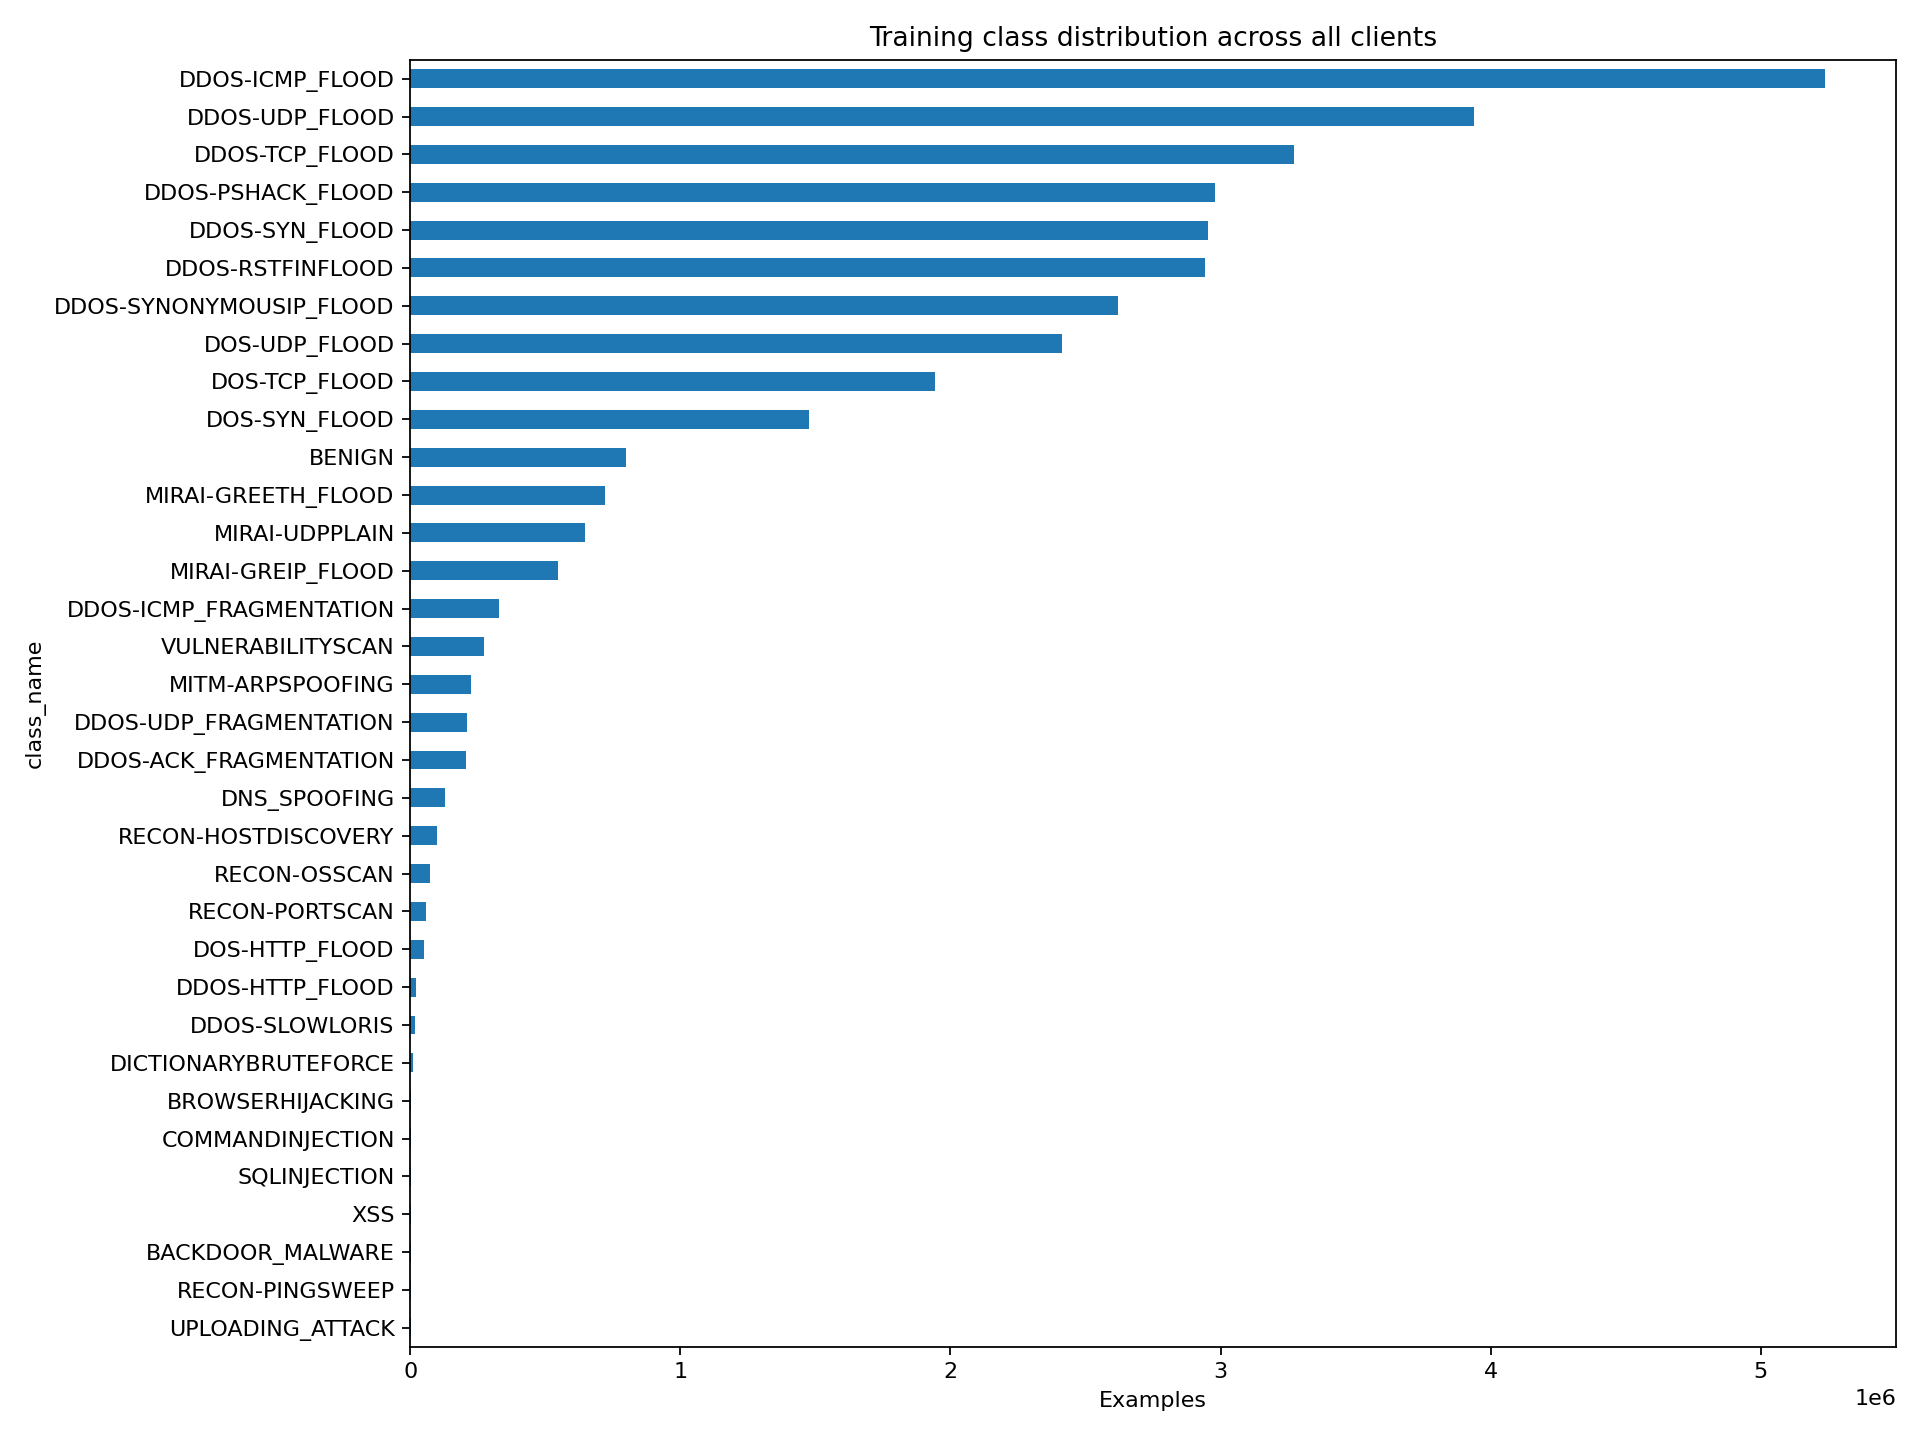

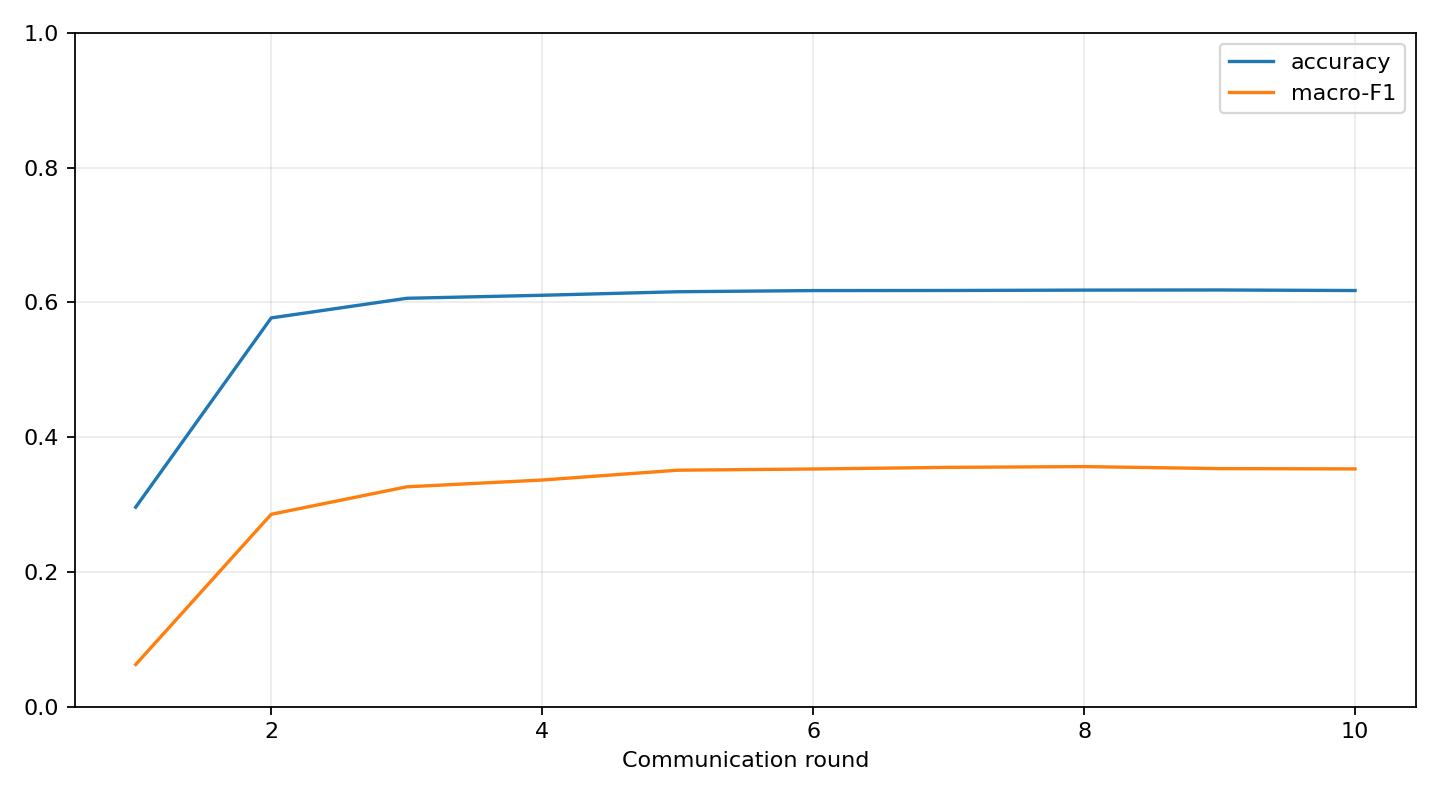

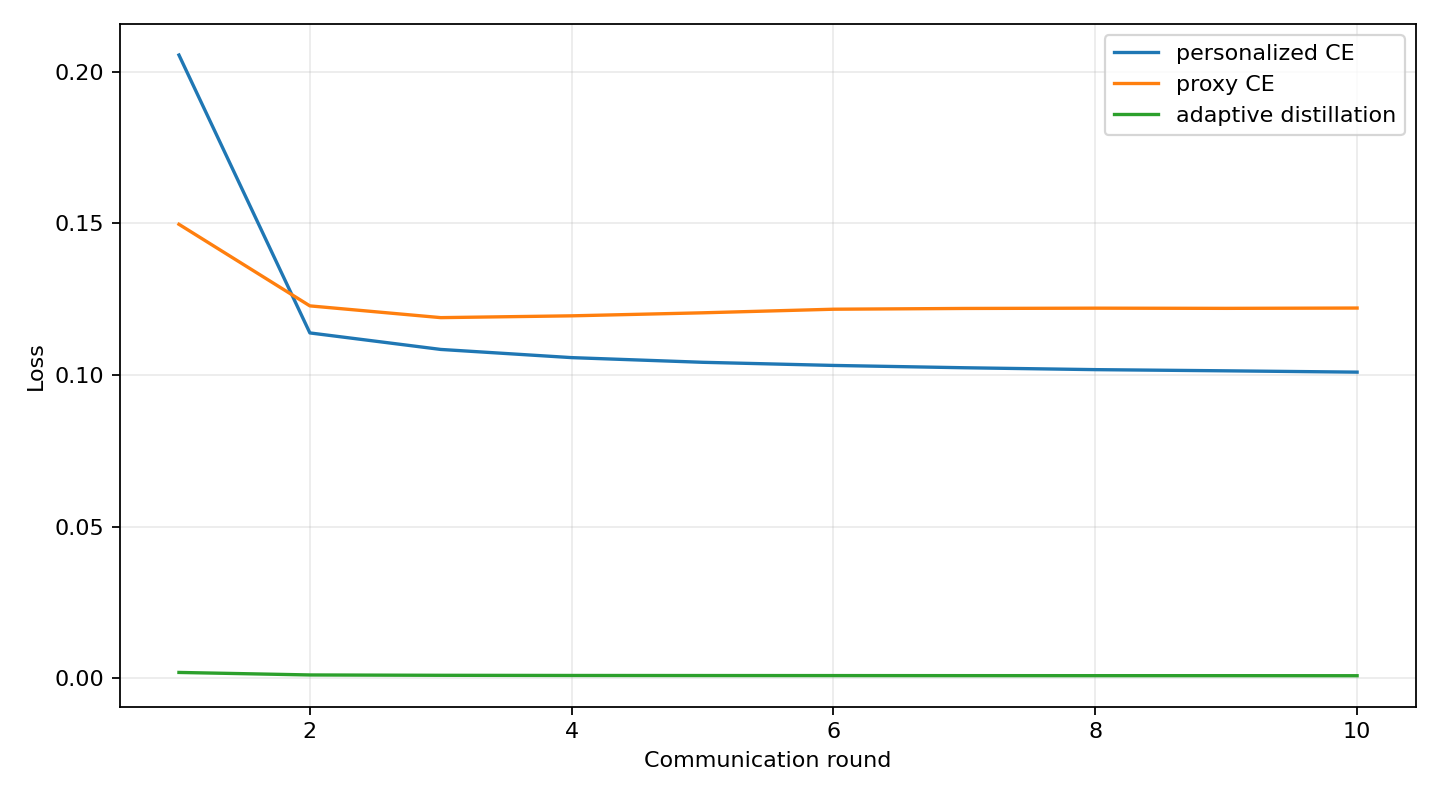

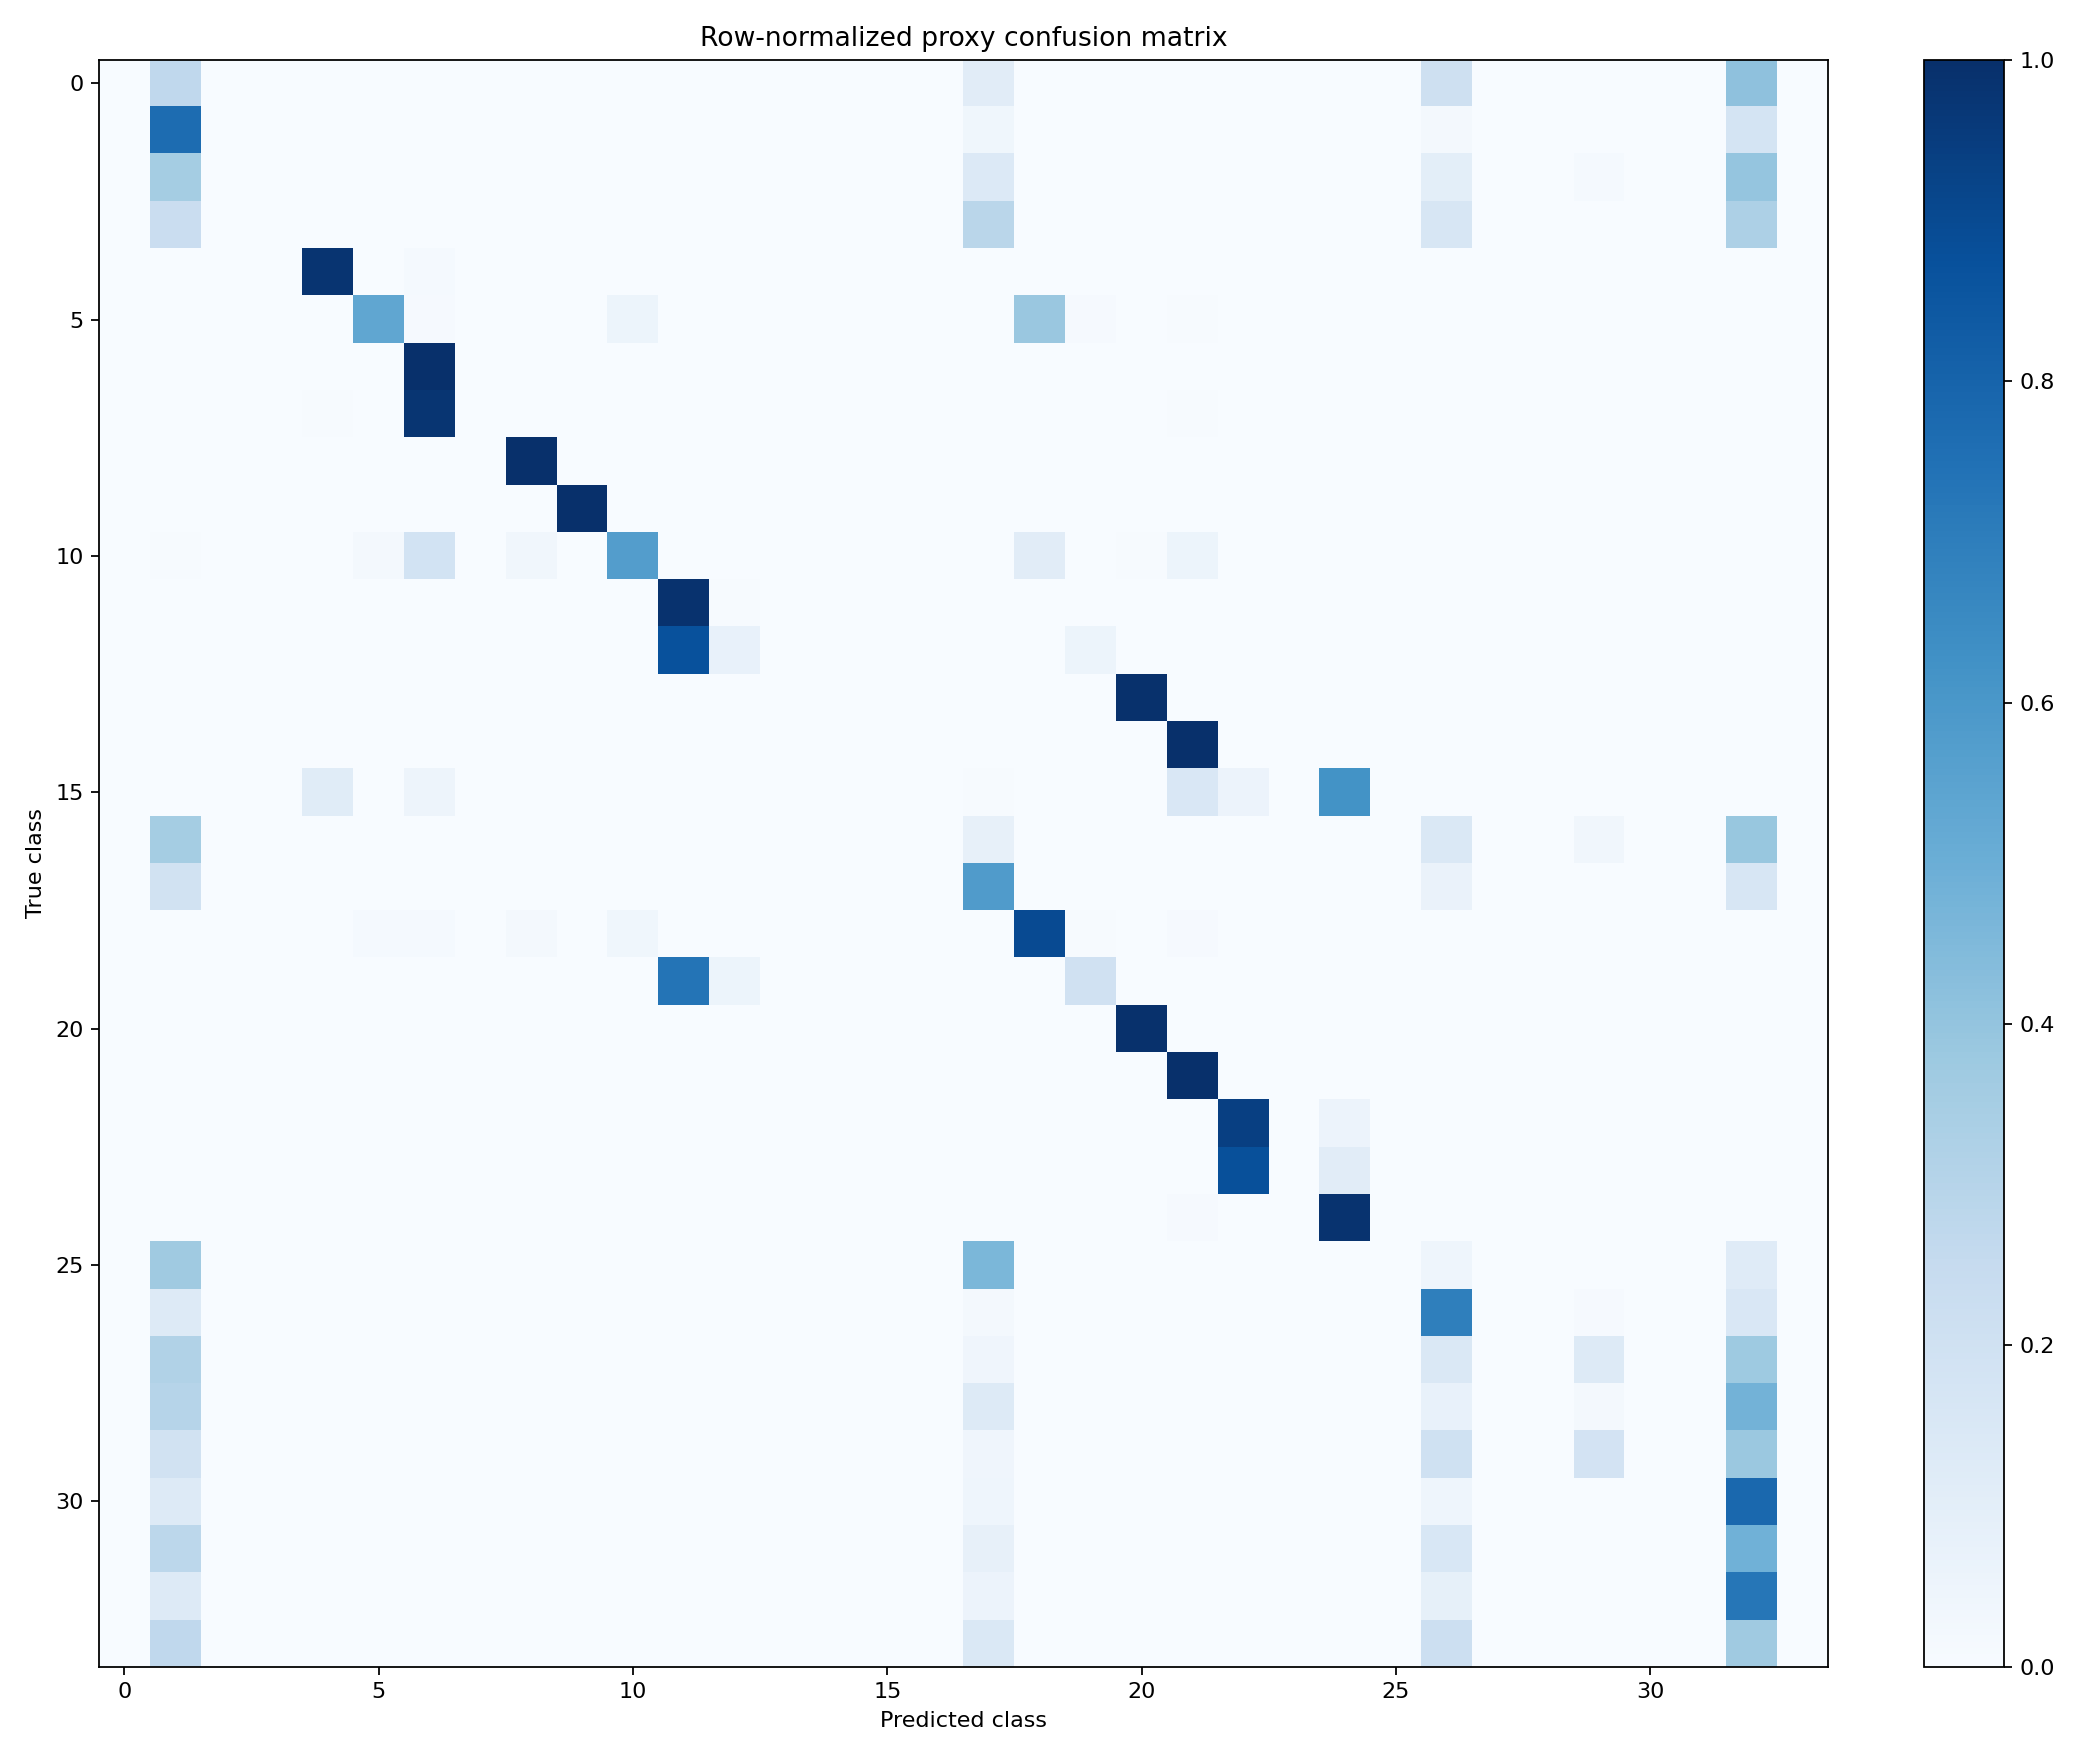

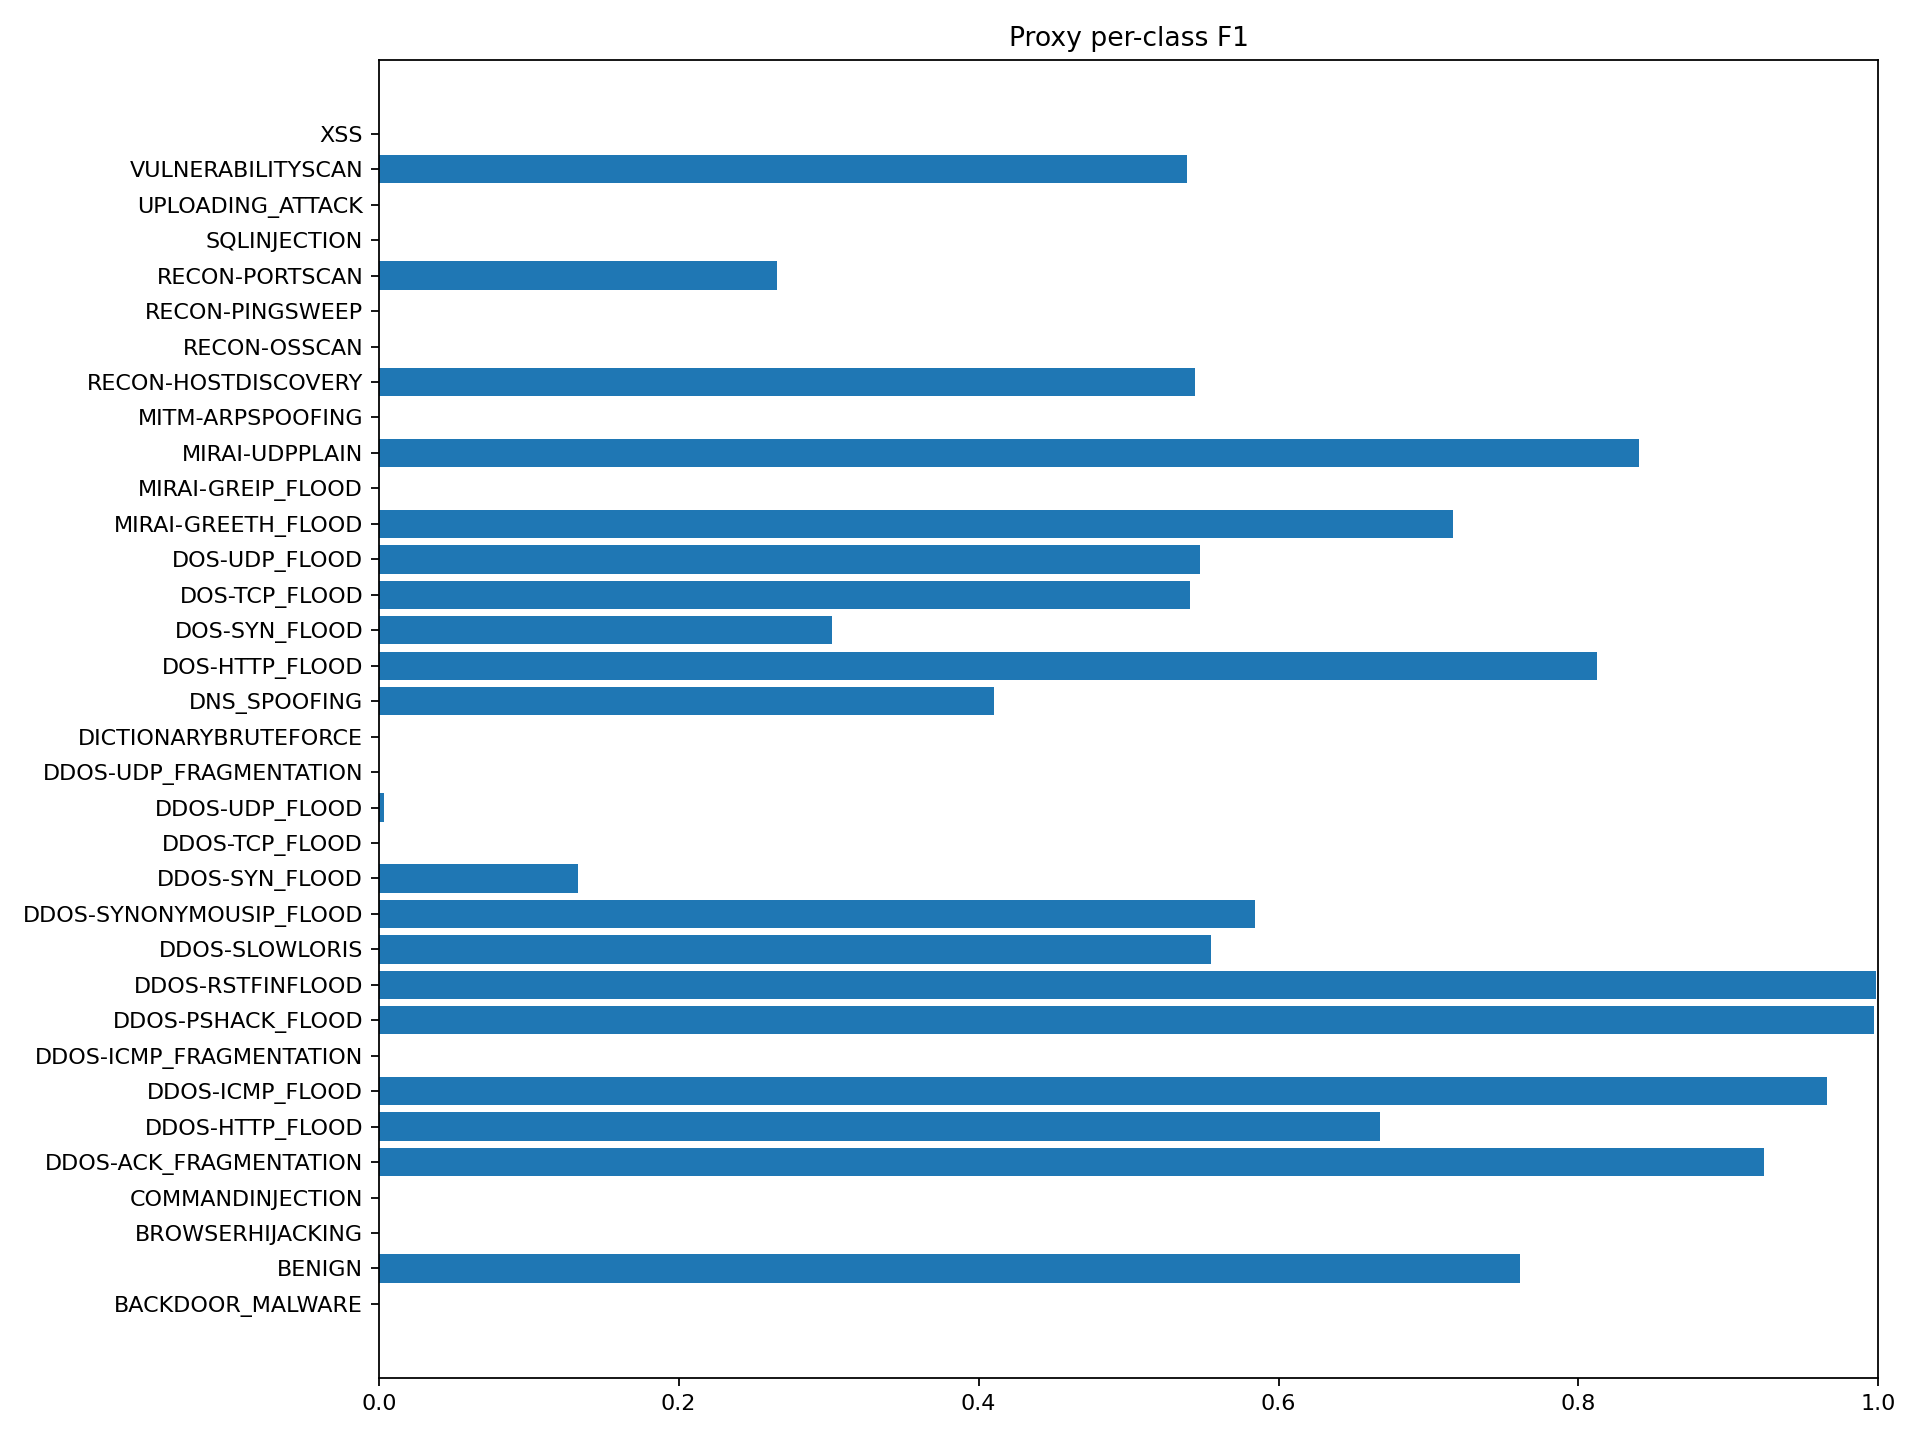

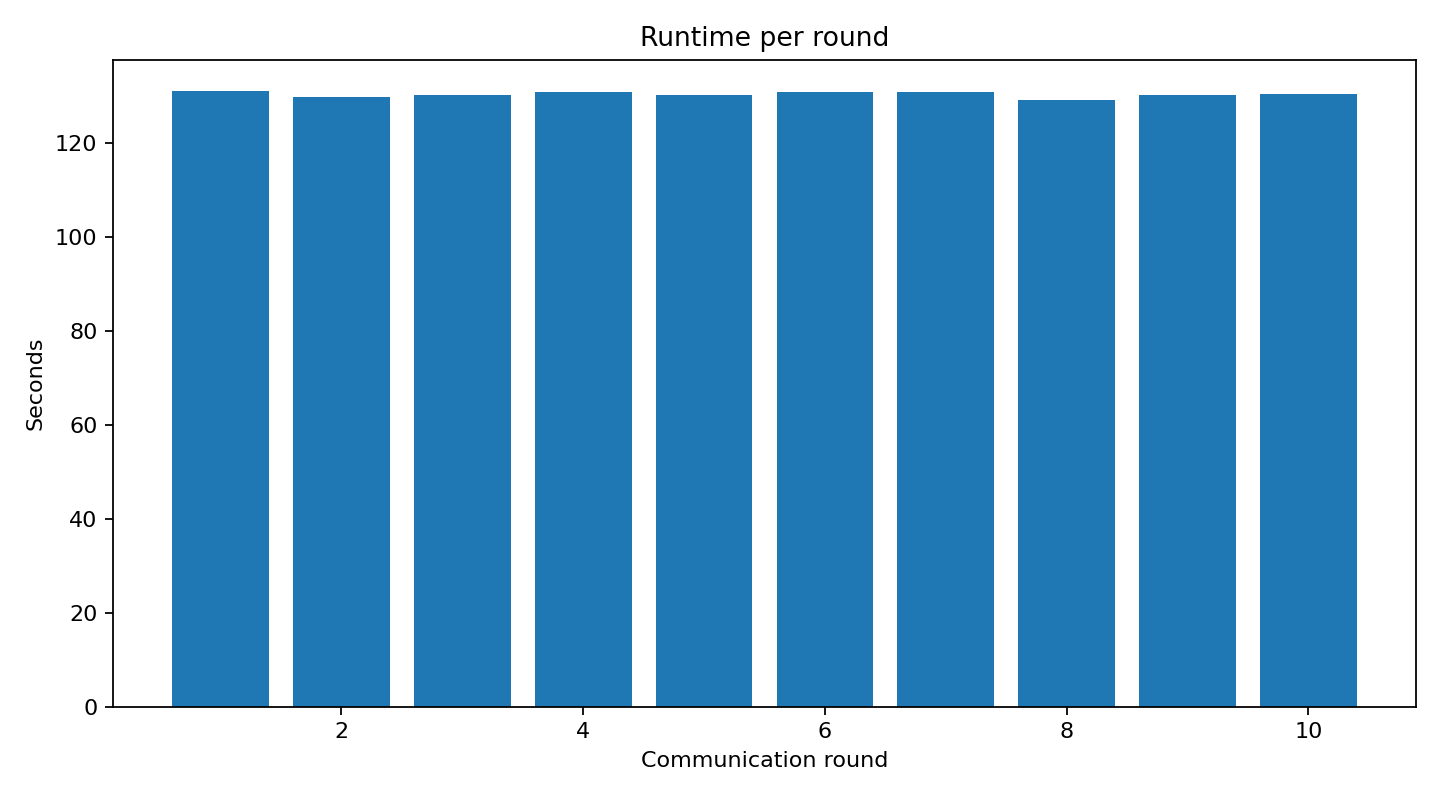

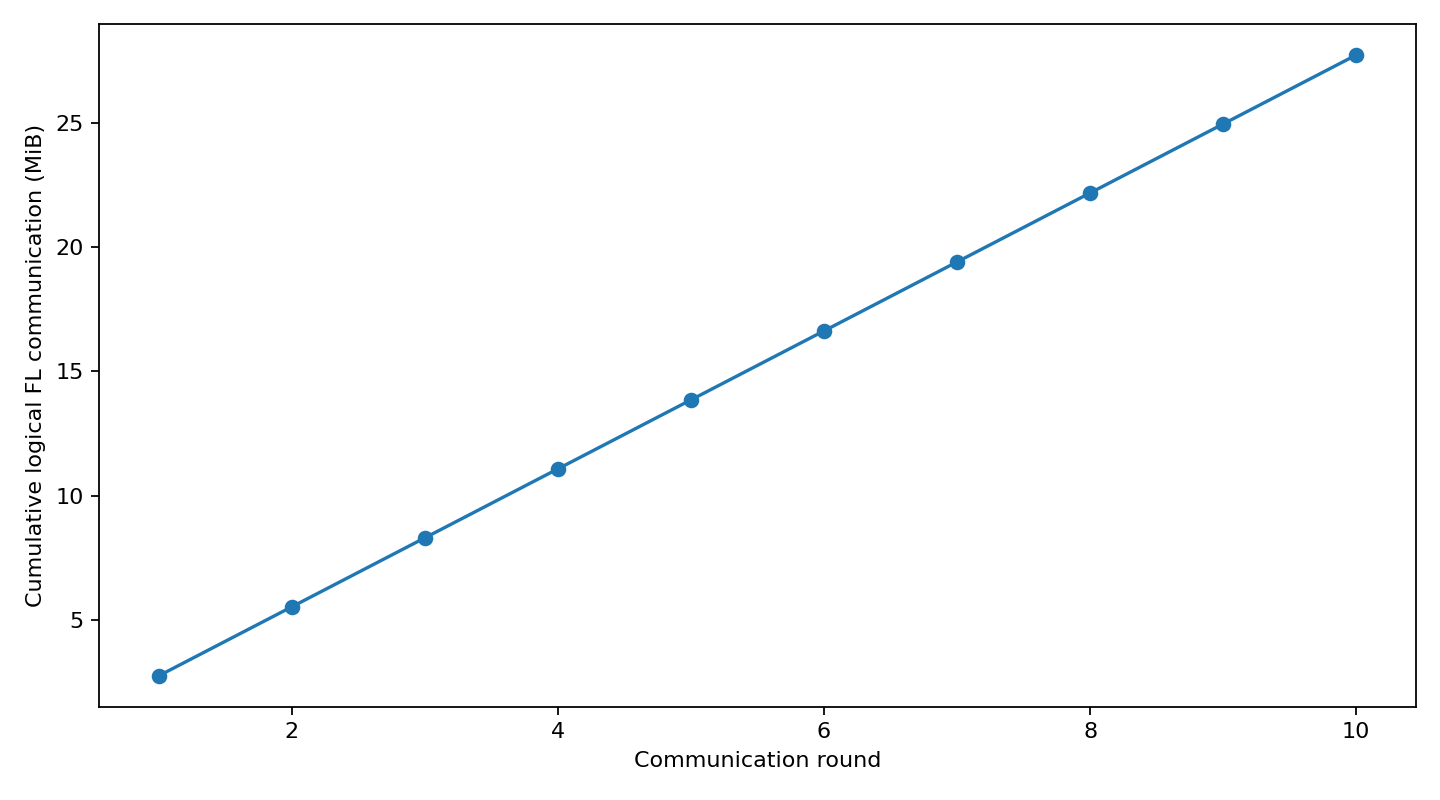

In [6]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
    handlers=[
        logging.FileHandler(LOG_FILE, mode="a", encoding="utf-8"),
        logging.StreamHandler(sys.stdout),
    ],
    force=True,
)
logger = logging.getLogger("training")
runtime_path = OUT / "metrics" / "runtime_breakdown.json"
summary_path = OUT / "metrics" / "summary.json"
runtime = json.loads(runtime_path.read_text(encoding="utf-8"))
runtime["subprocess_wall_seconds"] = subprocess_wall_seconds
runtime["total_notebook_pipeline_seconds"] = time.perf_counter() - pipeline_started
runtime_path.write_text(json.dumps(runtime, indent=2), encoding="utf-8")
summary = json.loads(summary_path.read_text(encoding="utf-8"))
summary["runtime_breakdown"] = runtime
summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")

required_relative_paths = summary["output_paths"]
required_outputs = [OUT / relative for relative in required_relative_paths]
missing = [str(path) for path in required_outputs if not path.is_file()]
empty = [
    str(path)
    for path in required_outputs
    if path.is_file() and path.stat().st_size == 0
]
assert not missing, f"Missing outputs: {missing}"
assert not empty, f"Empty outputs: {empty}"
assert len(pd.read_csv(OUT / "metrics" / "history_round.csv")) == CONFIG[
    "communication_rounds"
]
assert len(pd.read_csv(OUT / "metrics" / "history_client.csv")) == (
    CONFIG["communication_rounds"] * CONFIG["num_clients"]
)
history_round_frame = pd.read_csv(OUT / "metrics" / "history_round.csv")
history_client_frame = pd.read_csv(OUT / "metrics" / "history_client.csv")
history_local_frame = pd.read_csv(OUT / "metrics" / "history_local_epoch.csv")
expected_local_rows = (
    CONFIG["communication_rounds"]
    * CONFIG["num_clients"]
    * CONFIG["local_epochs"]
    + CONFIG["num_clients"]
    * CONFIG["final_personalized_finetune_epochs"]
)
assert len(history_local_frame) == expected_local_rows
assert (history_local_frame["sampler_padding_rows"] == 0).all()
assert set(history_local_frame["gpu_id"].astype(int)) == {0, 1}
assert set(history_local_frame["concurrent_streams"].astype(int)) <= {1, 2}
for gpu_id in range(2):
    for memory_name in ("peak_allocated", "peak_reserved"):
        assert f"gpu_{gpu_id}_{memory_name}_bytes" in history_round_frame
        assert f"gpu_{gpu_id}_{memory_name}_mib" in history_round_frame

required_checkpoint_keys = {
    "model_state_dict",
    "personalized_model_state_dicts",
    "initial_model_state_dicts_by_family",
    "initialization_hashes",
    "round",
    "config",
    "feature_columns",
    "label_mapping",
    "validation_metrics",
    "model_metadata",
}
best_checkpoint = torch.load(
    OUT / "checkpoints" / "best.pt",
    map_location="cpu",
    weights_only=False,
)
last_checkpoint = torch.load(
    OUT / "checkpoints" / "last.pt",
    map_location="cpu",
    weights_only=False,
)
assert required_checkpoint_keys <= set(best_checkpoint)
assert required_checkpoint_keys <= set(last_checkpoint)
assert "personalized_model_state_dicts_before_finetune" in best_checkpoint
assert "personalized_model_state_dicts_before_finetune" not in last_checkpoint
assert len(best_checkpoint["personalized_model_state_dicts"]) == 10
assert not any(
    key.startswith("module.")
    for key in best_checkpoint["model_state_dict"]
)
assert (
    best_checkpoint["initialization_hashes"]
    == last_checkpoint["initialization_hashes"]
    == summary["initialization_hashes"]
)
for family, metadata in summary["model_metadata"].items():
    assert (
        metadata["initialization_sha256"]
        == summary["initialization_hashes"][family]
    )
assert summary["execution_mode"] == CONFIG["execution_mode"] == "client_parallel"
assert CONFIG["per_client_batch_size"] == 1024
logger.info("Verified %d required non-empty outputs", len(required_outputs))
logger.info("Initialization hashes: %s", summary["initialization_hashes"])
logger.info(
    "Final proxy accuracy=%.6f macro-F1=%.6f",
    summary["final_test_metrics"]["accuracy"],
    summary["final_test_metrics"]["macro_f1"],
)

from IPython.display import Image, display

for artifact_name in (
    "class_distribution.png",
    "accuracy_f1_curves.png",
    "loss_curves.png",
    "confusion_matrix.png",
    "per_class_f1.png",
    "runtime_per_round.png",
    "communication_cumulative.png",
):
    display(Image(filename=str(OUT / "artifacts" / artifact_name)))